In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns

In [3]:
# ══════════════════════════════════════════════════════
# # Tickers dos índices
# ══════════════════════════════════════════════════════
ticker_idx_sp100 = '^OEX'
ticker_idx_ibov = '^BVSP'

In [5]:
# ══════════════════════════════════════════════════════
# Período de análise
# ══════════════════════════════════════════════════════
data_inicio = "2023-01-01"
data_fim = "2026-10-02"

In [6]:
# ══════════════════════════════════════════════════════
#Definindo as ações do SP100 e IBOVESPA
# ══════════════════════════════════════════════════════
SP100 = pd.read_csv("SP100_wikipedia_21set2026.csv", sep=",")
tickers_sp100 = SP100["Symbol"].tolist()
print(len(tickers_sp100), tickers_sp100) #Conferindo qnt e itens da lista

IBOVESPA = pd.read_csv("IBOVESPA_B3_24set2026.csv", sep=",")
tickers_ibov = IBOVESPA["Codigo"].tolist()
for i in range(len(tickers_ibov)): #loop para adicionar o sufixo ".SA" aos tickers do IBOVESPA
    tickers_ibov[i] = tickers_ibov[i] + ".SA"
print(len(tickers_ibov),tickers_ibov) #Conferindo qnt e itens da lista


101 ['AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE', 'AMAT', 'AMD', 'AMGN', 'AMT', 'AMZN', 'ANET', 'AVGO', 'AXP', 'BA', 'BAC', 'BKNG', 'BLK', 'BMY', 'BNY', 'BRK-B', 'C', 'CAT', 'CMCSA', 'COF', 'COP', 'COST', 'CRM', 'CSCO', 'CVS', 'CVX', 'DE', 'DELL', 'DHR', 'DIS', 'DUK', 'EMR', 'FDX', 'GD', 'GE', 'GEV', 'GILD', 'GM', 'GOOG', 'GOOGL', 'GS', 'HD', 'IBM', 'INTC', 'INTU', 'ISRG', 'JNJ', 'JPM', 'KO', 'LIN', 'LLY', 'LMT', 'LOW', 'LRCX', 'MA', 'MCD', 'MDLZ', 'MDT', 'META', 'MMM', 'MO', 'MRK', 'MS', 'MSFT', 'MU', 'NEE', 'NFLX', 'NOW', 'NVDA', 'ORCL', 'PANW', 'PEP', 'PFE', 'PG', 'PLTR', 'PM', 'QCOM', 'RTX', 'SBUX', 'SCHW', 'SNDK', 'SO', 'T', 'TMO', 'TMUS', 'TSLA', 'TXN', 'UBER', 'UNH', 'UNP', 'UPS', 'USB', 'V', 'VZ', 'WFC', 'WMT', 'XOM']
76 ['ALOS3.SA', 'ABEV3.SA', 'ASAI3.SA', 'AURE3.SA', 'AXIA3.SA', 'AZZA3.SA', 'B3SA3.SA', 'BBSE3.SA', 'BBDC3.SA', 'BBDC4.SA', 'BRAP4.SA', 'BBAS3.SA', 'BRAV3.SA', 'BPAC11.SA', 'CXSE3.SA', 'CEAB3.SA', 'CMIG4.SA', 'COGN3.SA', 'CSMG3.SA', 'CPLE3.SA', 'CSAN3.SA', 'CPFE3.SA', 'C

In [7]:
# ══════════════════════════════════════════════════════
#Extraindo os dados do SP100 e IBOVESPA do Yahoo Finance
# ══════════════════════════════════════════════════════
print("Baixando S&P100...")
dados_sp100 = yf.download(tickers_sp100, start=data_inicio, end=data_fim, auto_adjust=True, progress=False)['Close']
indice_sp100 = yf.download(ticker_idx_sp100, start=data_inicio, end=data_fim, auto_adjust=True, progress=False)['Close']

print("Baixando IBOVESPA...")
dados_ibov = yf.download(tickers_ibov, start=data_inicio, end=data_fim, auto_adjust=True, progress=False)['Close']
indice_ibov = yf.download(ticker_idx_ibov, start=data_inicio, end=data_fim, auto_adjust=True, progress=False)['Close']

print("Tudo pronto!")

Baixando S&P100...
Baixando IBOVESPA...
Tudo pronto!


In [8]:
# ══════════════════════════════════════════════════════
#Salvando localmente
# ══════════════════════════════════════════════════════
dados_sp100.to_csv('sp100_precos.csv')
dados_ibov.to_csv('ibov_precos.csv')
indice_sp100.to_csv('sp100_indice.csv')
indice_ibov.to_csv('ibov_indice.csv')

# ══════════════════════════════════════════════════════
#Verificação rápida
# ══════════════════════════════════════════════════════
print(f'\n✅ S&P100: {dados_sp100.shape[1]} ações × {dados_sp100.shape[0]} pregões')
print(f'✅ IBOV: {dados_ibov.shape[1]} ações × {dados_ibov.shape[0]} pregões')
print(f'\nPeríodo S&P100: {dados_sp100.index[0].date()} → {dados_sp100.index[-1].date()}')
print(f'Período IBOV: {dados_ibov.index[0].date()} → {dados_ibov.index[-1].date()}')
print('\nPrimeiras linhas S&P100:')
print(dados_sp100.head(1))

print('\nPrimeiras linhas Ibovespa:')
print(dados_ibov.head(1))


✅ S&P100: 101 ações × 940 pregões
✅ IBOV: 76 ações × 937 pregões

Período S&P100: 2023-01-03 → 2026-10-01
Período IBOV: 2023-01-02 → 2026-10-01

Primeiras linhas S&P100:
Ticker           AAPL        ABBV         ABT         ACN        ADBE  \
Date                                                                    
2023-01-03  122.87674  142.123566  101.484192  252.926987  336.920013   

Ticker           AMAT        AMD        AMGN         AMT   AMZN  ...  \
Date                                                             ...   
2023-01-03  93.822166  64.019997  232.962997  188.215683  85.82  ...   

Ticker           UBER         UNH         UNP         UPS       USB  \
Date                                                                  
2023-01-03  25.360001  481.460907  190.587143  143.656433  37.62685   

Ticker               V         VZ        WFC        WMT        XOM  
Date                                                                
2023-01-03  201.544922  31.214211  38.01

In [9]:
# ══════════════════════════════════════════════════════
# Calcular retornos,FAZER ISSO LOGO APÓS O DOWNLOAD
# ══════════════════════════════════════════════════════

#  1. Retorno logarítmico diário
ret_sp100 = np.log(dados_sp100 / dados_sp100.shift(1)).dropna(how='all') #Usar shift(5) para obter o retorno da semana útil
ret_ibov = np.log(dados_ibov / dados_ibov.shift(1)).dropna(how='all')

ret_idx_sp = np.log(indice_sp100 / indice_sp100.shift(1)).dropna()
ret_idx_ib = np.log(indice_ibov / indice_ibov.shift(1)).dropna()

# 2. Garantir extração de valores escalares para impressão (funciona para Series ou DataFrames)
val_media_sp = ret_idx_sp.values.mean() if isinstance(ret_idx_sp, pd.DataFrame) else ret_idx_sp.mean()
val_media_ib = ret_idx_ib.values.mean() if isinstance(ret_idx_ib, pd.DataFrame) else ret_idx_ib.mean()

val_std_sp = ret_idx_sp.values.std() if isinstance(ret_idx_sp, pd.DataFrame) else ret_idx_sp.std()
val_std_ib = ret_idx_ib.values.std() if isinstance(ret_idx_ib, pd.DataFrame) else ret_idx_ib.std()

# Formato das matrizes
print('Formato dos retornos S&P100:', ret_sp100.shape)
print('Formato dos retornos IBOV:  ', ret_ibov.shape)

# Exibição das estatísticas do benchmark
print(f'\nRetorno médio diário do S&P100: {val_media_sp:.1%}')
print(f'Retorno médio diário do IBOV:   {val_media_ib:.1%}')

print(f'\nVolatilidade diária S&P100:     {val_std_sp:.1%}')
print(f'Volatilidade diária IBOV:       {val_std_ib:.1%}')

# 3. Salvar retornos tratados
ret_sp100.to_csv('sp100_retornos.csv') #datafram dos retornos de todas as ações do S&P100
ret_ibov.to_csv('ibov_retornos.csv') #dataframe dos retornos de todas as ações do IBOVESPA
ret_idx_sp.to_csv('sp100_indice_retornos.csv') #dataframe do retorno do indice S&P100
ret_idx_ib.to_csv('ibov_indice_retornos.csv') #dataframe do retorno do indice IBOVESPA

Formato dos retornos S&P100: (939, 101)
Formato dos retornos IBOV:   (936, 76)

Retorno médio diário do S&P100: 0.1%
Retorno médio diário do IBOV:   0.1%

Volatilidade diária S&P100:     1.0%
Volatilidade diária IBOV:       1.0%


In [26]:
# 1. Definição da função de estilo
def set_nyt_style():
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['figure.facecolor'] = '#FFFFFF'
    plt.rcParams['axes.facecolor'] = '#FFFFFF'
    plt.rcParams['axes.edgecolor'] = '#CCCCCC'
    plt.rcParams['axes.linewidth'] = 0.8
    plt.rcParams['grid.color'] = '#E5E5E5'
    plt.rcParams['grid.linestyle'] = '--'
    plt.rcParams['grid.alpha'] = 0.7
    
    # Remover bordas superiores e da direita (spines)
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.left'] = True
    plt.rcParams['axes.spines.bottom'] = True
    
    plt.rcParams['xtick.color'] = '#333333'
    plt.rcParams['ytick.color'] = '#333333'
    plt.rcParams['axes.labelcolor'] = '#222222'
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.titleweight'] = 'bold'

# 2. Chama a função UMA VEZ para aplicar a todos os gráficos do notebook
set_nyt_style()

# 3. Define a paleta de cores padrão dos dois índices para reusar no projeto
CORES = {
    'sp100': '#0F4C81',   # Azul Marinho
    'ibov': '#1B4D3E',    # Verde Esmeralda Fechado
    'alerta': '#C53030',   # Vermelho para Destaques/Erros
    'neutro': '#A0AEC0' # Cinza para fundo/outros ativos
}

=== DADOS FALTANTES,S&P100 ===
Total de ações: 101
Ações sem nenhum dado faltante: 99
Ações com algum dado faltante: 2

Ações com até 5% de dados faltantes:
Series([], dtype: float64)

Ações com mais de 5% de dados faltantes:
Ticker
SNDK    56.38
GEV     32.87
dtype: float64


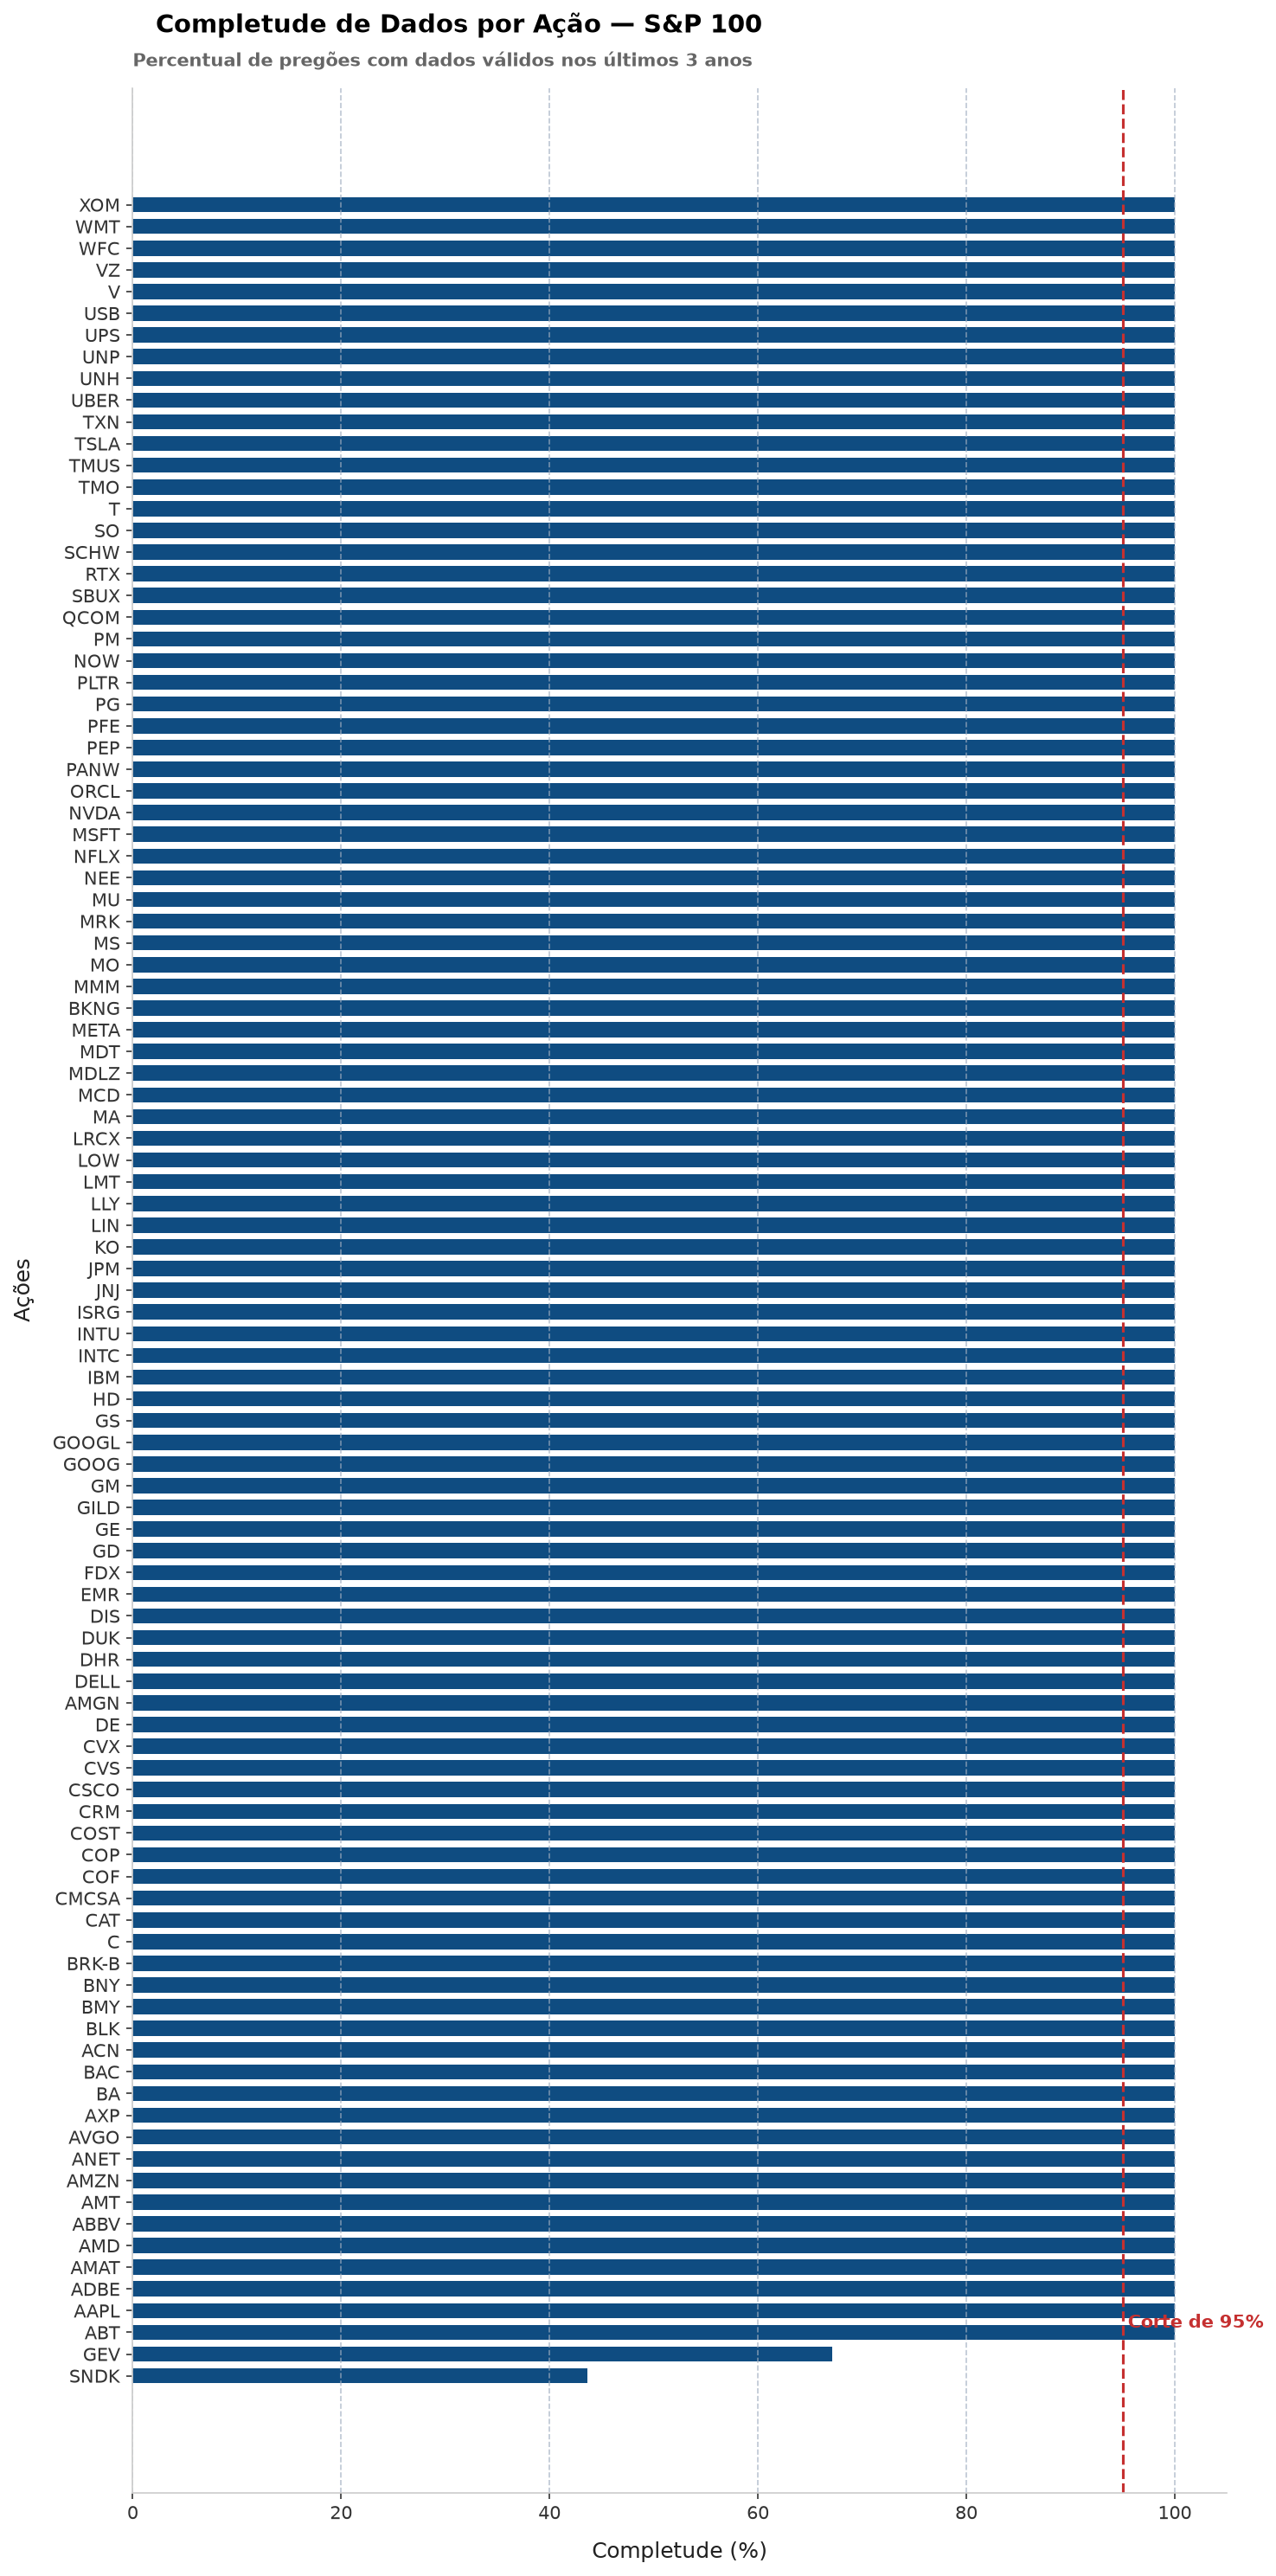

=== DADOS FALTANTES,IBOVESPA ===
Total de ações: 76
Ações sem nenhum dado faltante: 75
Ações com algum dado faltante: 1

Ações com até 5% de dados faltantes:
Series([], dtype: float64)

Ações com mais de 5% de dados faltantes:
Ticker
NATU3.SA    65.96
dtype: float64


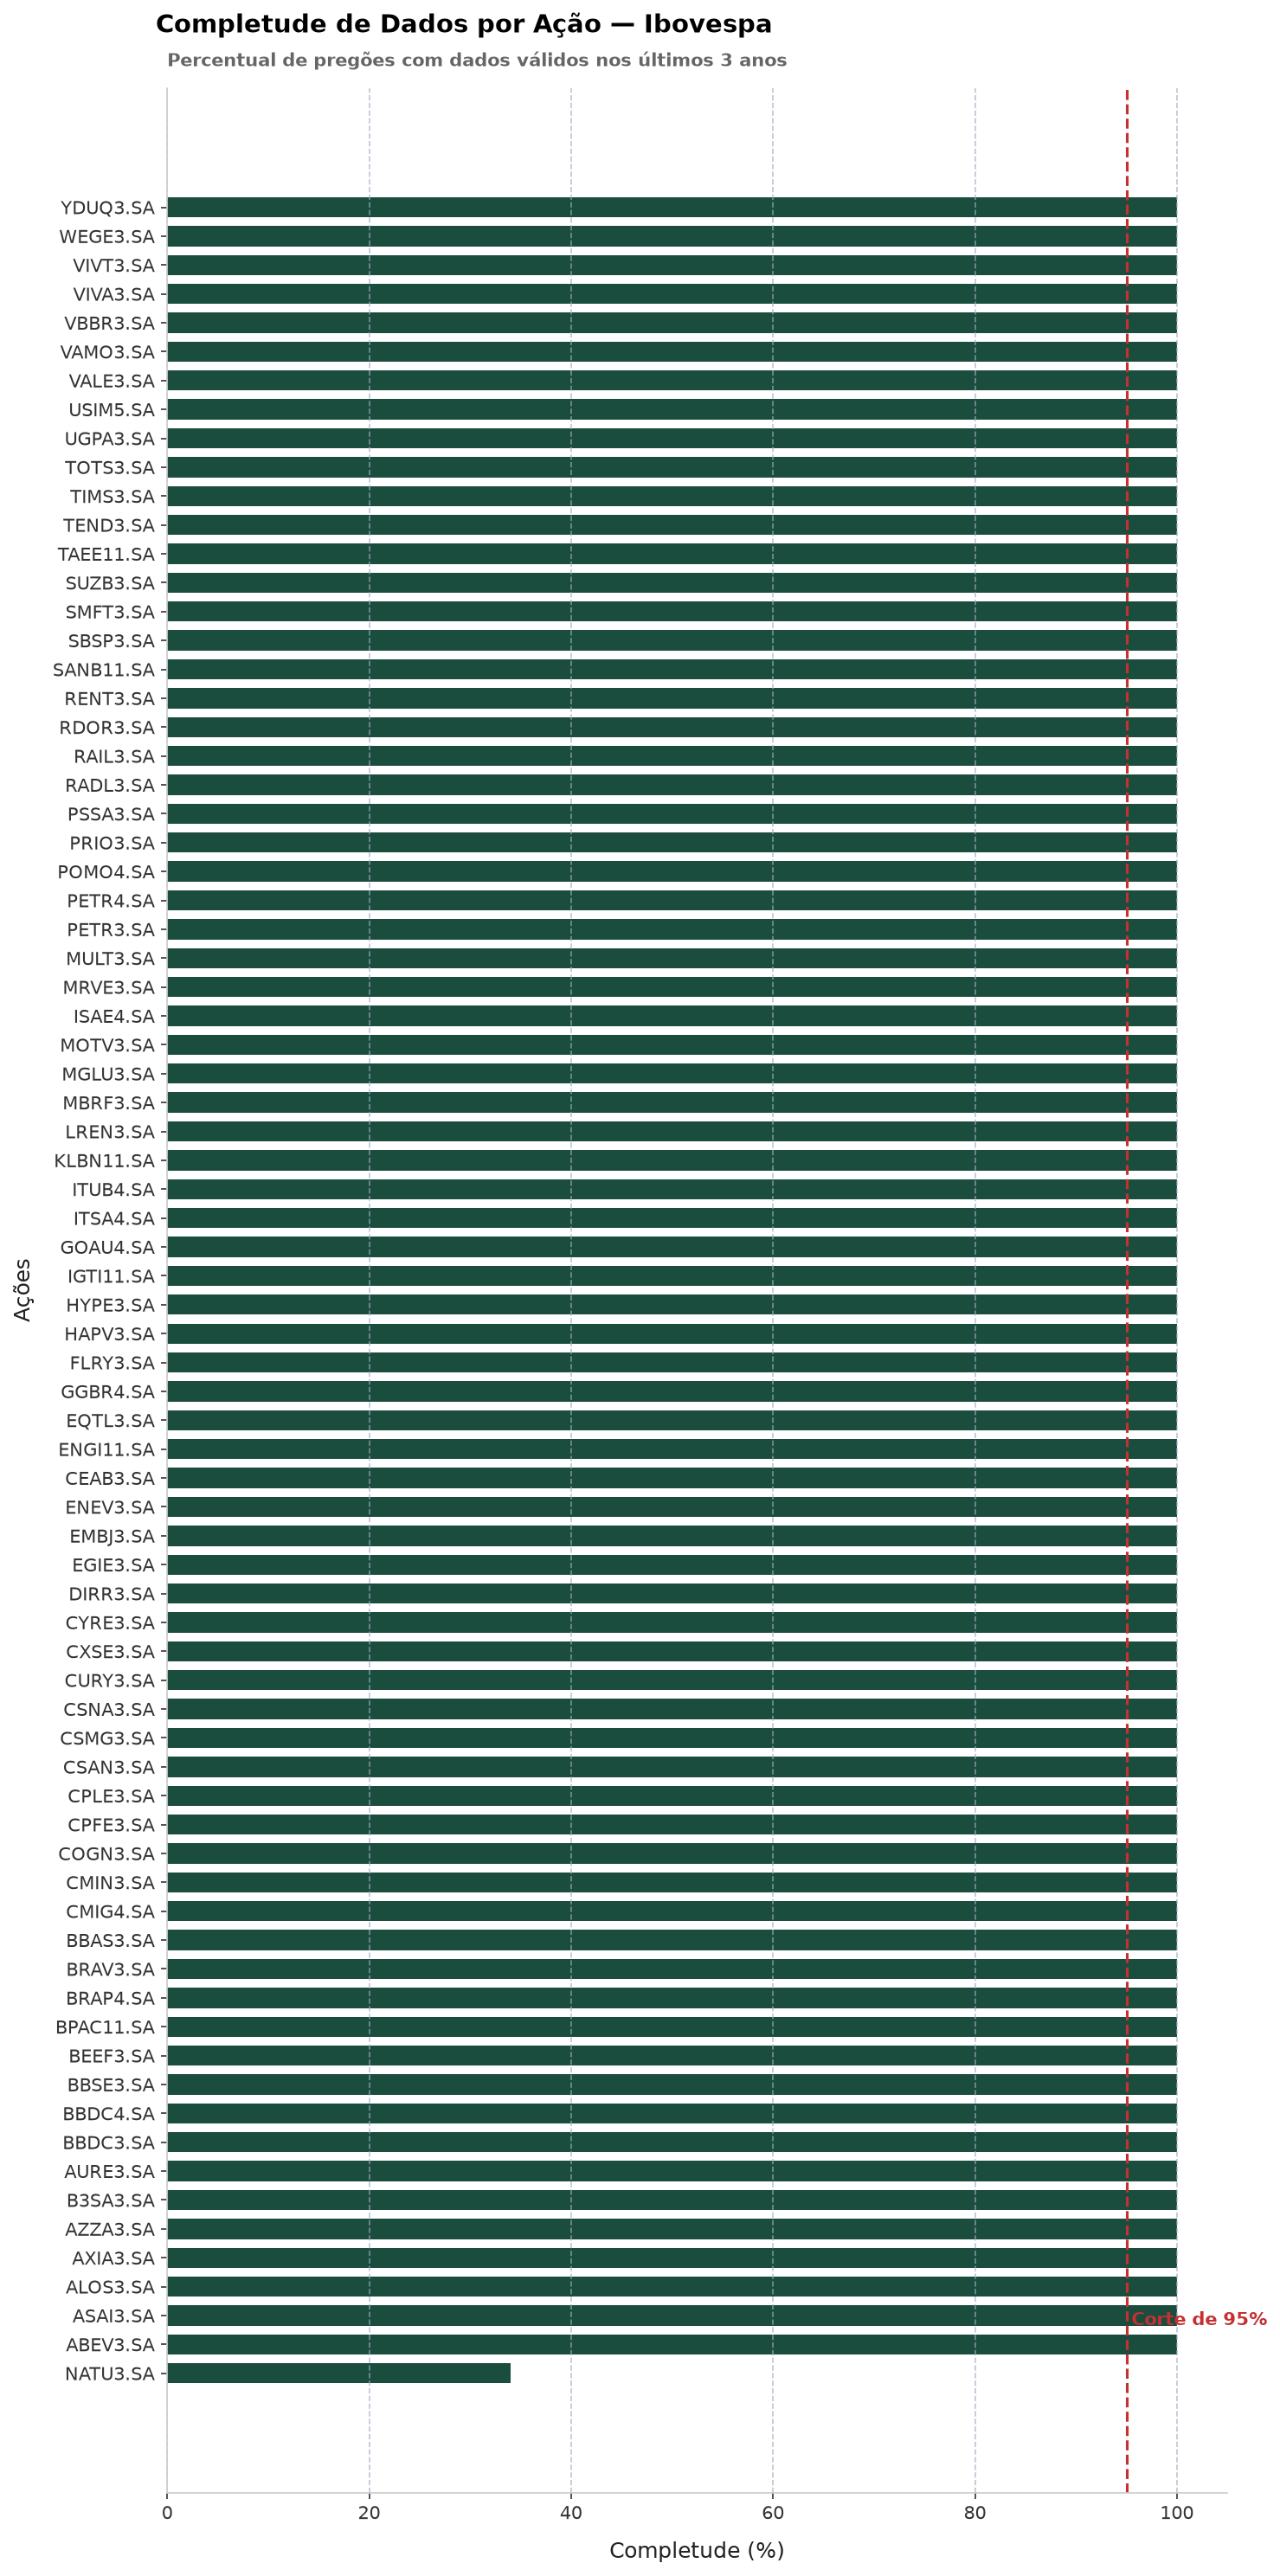

In [30]:
# ══════════════════════════════════════════════════════
# DIAGNÓSTICO DE DADOS FALTANTES, S&P100
# ══════════════════════════════════════════════════════

# Contagem e percentual de nulos por ação
nulos_sp = dados_sp100.isnull().sum()
pct_nulos = (nulos_sp / len(dados_sp100) * 100).round(2)
print('=== DADOS FALTANTES,S&P100 ===')
print(f'Total de ações: {dados_sp100.shape[1]}')
print(f'Ações sem nenhum dado faltante: {(pct_nulos == 0).sum()}')
print(f'Ações com algum dado faltante: {(pct_nulos > 0).sum()}')
print("\nAções com até 5% de dados faltantes:")
print(pct_nulos[pct_nulos.between(0, 5, inclusive='right')])
print(f'\nAções com mais de 5% de dados faltantes:')
print(pct_nulos[pct_nulos > 5].sort_values(ascending=False))

# Visualização,mapa de calor de dados faltantes
completude = (dados_sp100.notnull().mean() * 100).sort_values(ascending=True) # Calcula a completude em porcentagem para cada ação
set_nyt_style()
fig, ax = plt.subplots(figsize=(10, 20), dpi=150)
ax.barh(completude.index, completude.values, color=CORES['sp100'], height=0.7) #Plota as barras horizontais
ax.axvline(x=95, color=CORES['alerta'], linestyle='--', linewidth=1.5, label='Limite de 95%') #Adiciona a linha pontilhada em 95% (Destaque)
# Configuração de eixos e limites
ax.set_xlim(0, 105) # Limite até 105% para dar margem visual no topo
ax.set_xlabel("Completude (%)", fontsize=12, labelpad=10)
ax.set_ylabel("Ações", fontsize=12, labelpad=10)
#Definindo o Título e Subtítulo no estilo NYT
plt.suptitle('Completude de Dados por Ação — S&P 100', x=0.125, y=0.99, fontweight='bold', fontsize=14, ha='left')
ax.set_title('Percentual de pregões com dados válidos nos últimos 3 anos', fontsize=10, color='#666666', pad=12, loc='left')
#Inserir um rótulo de texto diretamente na linha de 95% em vez de usar legenda comum
ax.text(95.5, len(completude)*0.02, 'Corte de 95%', color=CORES['alerta'], fontweight='bold', fontsize=10, va='bottom')
ax.grid(axis='x', color=CORES['neutro'], linestyle='--', alpha=0.7) #suave apenas no eixo X para facilitar a leitura da porcentagem
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.savefig('missing_sp100.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════
# DIAGNÓSTICO DE DADOS FALTANTES, IBOVESPA
# ══════════════════════════════════════════════════════

# Contagem e percentual de nulos por ação
nulos_sp = dados_ibov.isnull().sum()
pct_nulos = (nulos_sp / len(dados_ibov) * 100).round(2)
print('=== DADOS FALTANTES,IBOVESPA ===')
print(f'Total de ações: {dados_ibov.shape[1]}')
print(f'Ações sem nenhum dado faltante: {(pct_nulos == 0).sum()}')
print(f'Ações com algum dado faltante: {(pct_nulos > 0).sum()}')
print("\nAções com até 5% de dados faltantes:")
print(pct_nulos[pct_nulos.between(0, 5, inclusive='right')])
print(f'\nAções com mais de 5% de dados faltantes:')
print(pct_nulos[pct_nulos > 5].sort_values(ascending=False))

# Visualização,mapa de calor de dados faltantes

completude = (dados_ibov.notnull().mean() * 100).sort_values(ascending=True) # Calcula a completude em porcentagem para cada ação
set_nyt_style()
fig, ax = plt.subplots(figsize=(10, 20), dpi=150)
ax.barh(completude.index, completude.values, color=CORES['ibov'], height=0.7) #Plota as barras horizontais
ax.axvline(x=95, color=CORES['alerta'], linestyle='--', linewidth=1.5, label='Limite de 95%') #Adiciona a linha pontilhada em 95% (Destaque)
# Configuração de eixos e limites
ax.set_xlim(0, 105) # Limite até 105% para dar margem visual no topo
ax.set_xlabel("Completude (%)", fontsize=12, labelpad=10)
ax.set_ylabel("Ações", fontsize=12, labelpad=10)
#Definindo o Título e Subtítulo no estilo NYT
plt.suptitle('Completude de Dados por Ação — Ibovespa', x=0.125, y=0.99, fontweight='bold', fontsize=14, ha='left')
ax.set_title('Percentual de pregões com dados válidos nos últimos 3 anos', fontsize=10, color='#666666', pad=12, loc='left')
#Inserir um rótulo de texto diretamente na linha de 95% em vez de usar legenda comum
ax.text(95.5, len(completude)*0.02, 'Corte de 95%', color=CORES['alerta'], fontweight='bold', fontsize=10, va='bottom')
ax.grid(axis='x', color=CORES['neutro'], linestyle='--', alpha=0.7) #suave apenas no eixo X para facilitar a leitura da porcentagem
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.savefig('missing_ibov.png', dpi=150, bbox_inches='tight')
plt.show()

IBOVESPA
Total de ações originais: 76
Total de ações mantidas:  75

S&P100
Total de ações originais: 101
Total de ações mantidas:  99

Retornos finais,IBOV: (936, 75)
Retornos finais,S&P100: (939, 99)


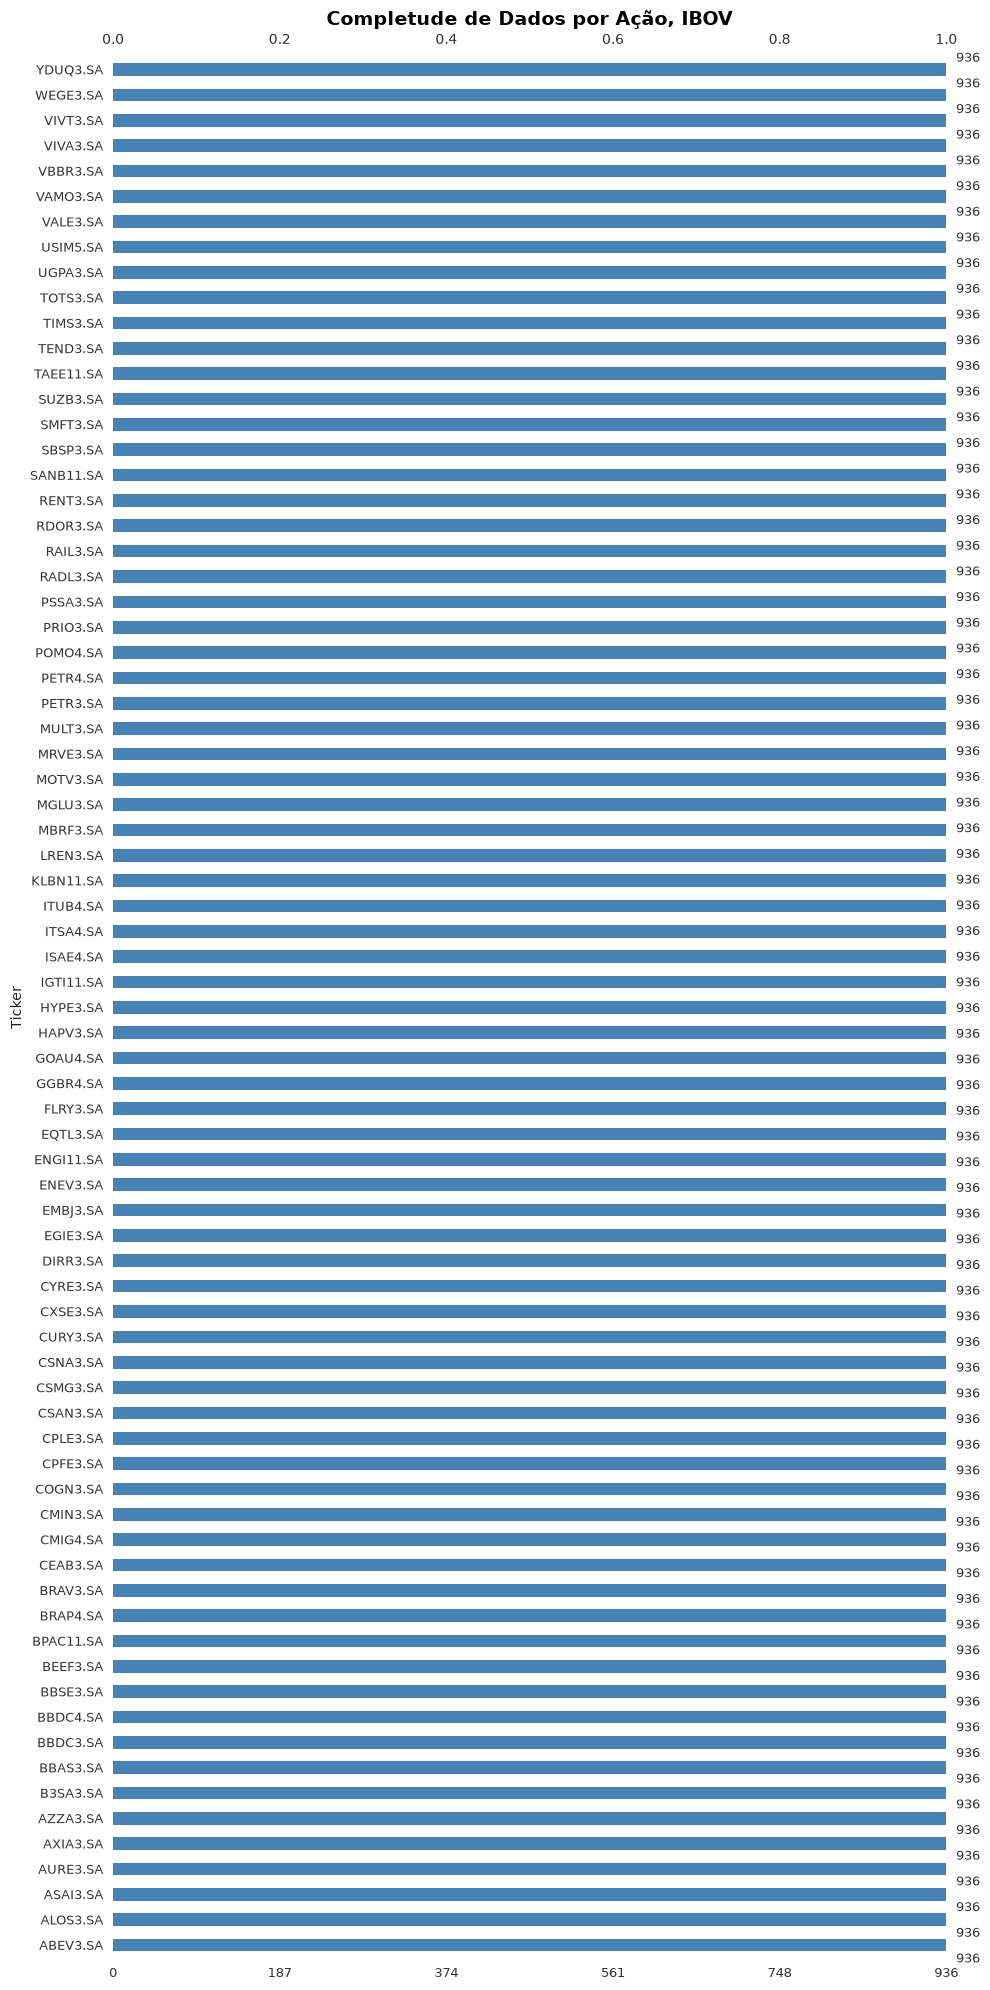

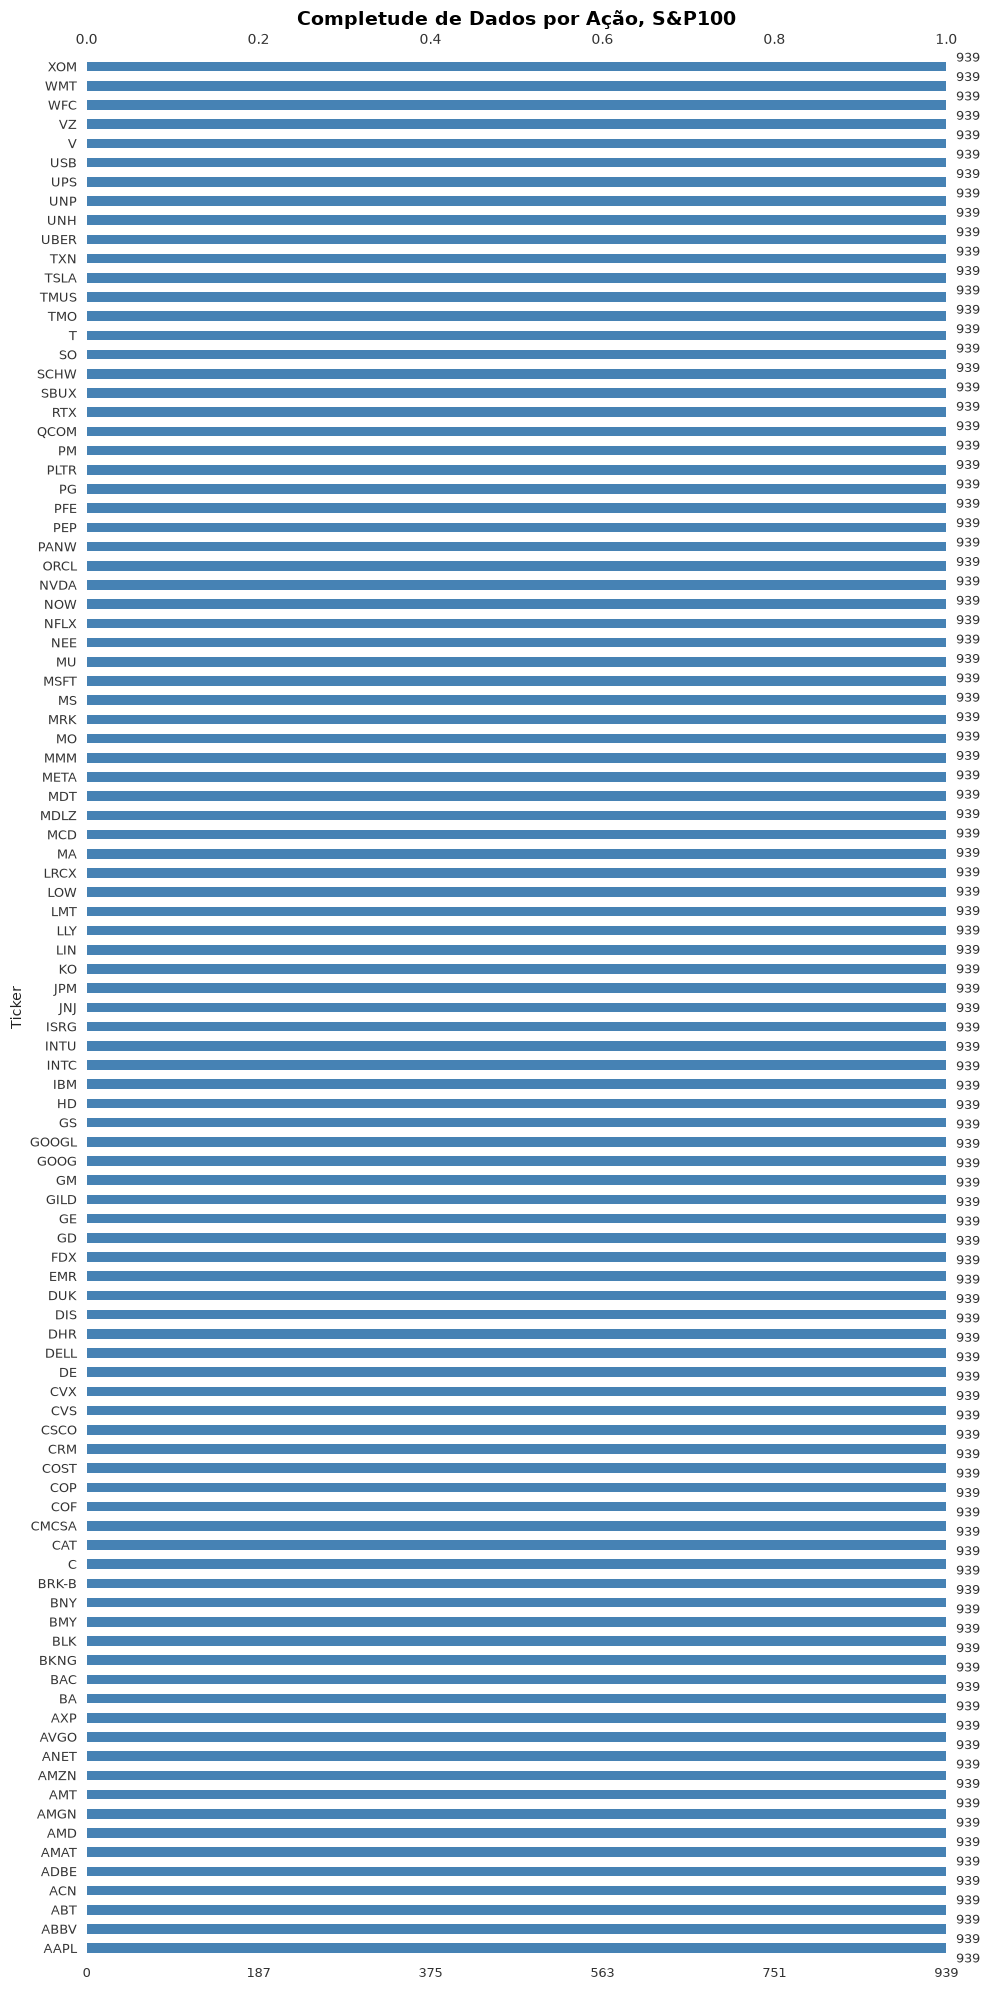

In [36]:
# ══════════════════════════════════════════════════════
# TRATAMENTO DE DADOS FALTANTES
# ══════════════════════════════════════════════════════

# 1. Definir o limite máximo tolerado de NaNs (ex: 5%)
limite_remocao = 5.0  

# 2. Calcular a porcentagem de nulos de CADA AÇÃO (por coluna)
pct_nulos_sp100 = dados_sp100.isna().mean() * 100
pct_nulos_ibov = dados_ibov.isna().mean() * 100

# 3. Filtrar as ações que estão DENTRO do limite e extrair os nomes
acoes_validas_sp100 = pct_nulos_sp100[pct_nulos_sp100 <= limite_remocao].index
acoes_validas_ibov = pct_nulos_ibov[pct_nulos_ibov <= limite_remocao].index

#Criando o novo DataFrame filtrado contendo apenas as ações válidas
dados_sp100_clean = dados_sp100[acoes_validas_sp100]
dados_ibov_clean = dados_ibov[acoes_validas_ibov]

# 4 Preencher dados faltantes (<5%) restantes com forward fill
dados_sp100_clean = dados_sp100_clean.ffill() # ffill preenche com o último valor disponível 
dados_ibov_clean = dados_ibov_clean.ffill()

# 5. Criar o novo DataFrame filtrado contendo apenas as ações válidas
dados_sp100_clean = dados_sp100[acoes_validas_sp100]
dados_ibov_clean = dados_ibov[acoes_validas_ibov]
print ("IBOVESPA")
print(f"Total de ações originais: {dados_ibov.shape[1]}")
print(f"Total de ações mantidas:  {len(acoes_validas_ibov)}")

print ("\nS&P100")
print(f"Total de ações originais: {dados_sp100.shape[1]}")
print(f"Total de ações mantidas:  {len(acoes_validas_sp100)}")

# 6. Verificar se ainda há nulos (linhas iniciais podem ter NaN)
dados_sp100_clean = dados_sp100_clean.dropna(how='all')
dados_ibov_clean = dados_ibov_clean.dropna(how='all')

# Recalcular retornos com dados limpos
ret_sp100_clean = np.log(dados_sp100_clean / dados_sp100_clean.shift(1)).dropna()
ret_ibov_clean = np.log(dados_ibov_clean / dados_ibov_clean.shift(1)).dropna()
print(f'\nRetornos finais,IBOV: {ret_ibov_clean.shape}')
print(f'Retornos finais,S&P100: {ret_sp100_clean.shape}')

# Visualização, mapa de calor de dados completos após limpeza
fig, ax = plt.subplots(figsize=(10, 20))
msno.bar(ret_ibov_clean, ax=ax, color='steelblue', fontsize=9)
ax.set_title('Completude de Dados por Ação, IBOV', fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 20))
msno.bar(ret_sp100_clean, ax=ax, color='steelblue', fontsize=9)
ax.set_title('Completude de Dados por Ação, S&P100', fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
# ══════════════════════════════════════════════════════
#Identificação de Outliers nos Retornos
# ══════════════════════════════════════════════════════

# Detectar retornos extremos por ação
limite_outlier = 0.15 # ±15% em um dia,ajuste conforme necessário
outliers_sp = (ret_sp100_clean.abs() > limite_outlier).sum()
print('Ações com retornos diários > 15% (S&P100):')
print(outliers_sp[outliers_sp > 0].sort_values(ascending=False).head(15))

outliers_ibov = (ret_ibov_clean.abs() > limite_outlier).sum()
print('\nAções com retornos diários > 15% (IBOV):')
print(outliers_ibov[outliers_ibov > 0].sort_values(ascending=False).head(15))

# ══════════════════════════════════════════════════════
#Aqui Investiga uma ação específica suspeita
# ══════════════════════════════════════════════════════
acao_suspeita = 'TSLA' # Substituir por qualquer ação do S&P100 ou IBOVESPA que você queira investigar
if acao_suspeita in ret_sp100_clean.columns:
    retornos_acao = ret_sp100_clean[acao_suspeita]
    dias_extremos = retornos_acao[retornos_acao.abs() > limite_outlier]
    print(f'\nDias com retorno extremo,{acao_suspeita}:')
    formato = len(dias_extremos)
    print(dias_extremos.sort_values(key=abs, ascending=False))
    print(f'Quantidade de dias extremos: {formato}')

Ações com retornos diários > 15% (S&P100):
Ticker
PLTR    9
DELL    7
MU      5
INTC    5
TSLA    5
NVDA    4
ANET    4
AMD     4
AVGO    3
UNH     3
CVS     2
CRM     2
META    2
SBUX    2
LRCX    2
dtype: int64

Ações com retornos diários > 15% (IBOV):
Ticker
HAPV3.SA    6
CEAB3.SA    5
MGLU3.SA    4
YDUQ3.SA    3
RADL3.SA    2
TEND3.SA    2
MBRF3.SA    2
BRAV3.SA    2
BEEF3.SA    1
BBDC4.SA    1
AZZA3.SA    1
AXIA3.SA    1
LREN3.SA    1
CYRE3.SA    1
CSAN3.SA    1
dtype: int64

Dias com retorno extremo,TSLA:
Date
2025-04-09    0.204491
2024-10-24    0.198187
2025-03-10   -0.167546
2026-07-23   -0.156931
2025-06-05   -0.153849
Name: TSLA, dtype: float64
Quantidade de dias extremos: 5


In [50]:
# ==============================================================================
# PASSO 1: ALINHAMENTO DE DATAS E CONVERSÃO SEGURA PARA SERIES
# ==============================================================================
datas_comuns = ret_idx_sp.index.intersection(ret_idx_ib.index)

# Se o seu DataFrame tiver apenas 1 coluna do índice (^OEX e ^BVSP), extraímos como Series:
# (Caso ret_idx_sp tenha 99 colunas, selecione a coluna do benchmark: ret_idx_sp['^OEX'])
s_sp = ret_idx_sp.loc[datas_comuns].squeeze()
s_ib = ret_idx_ib.loc[datas_comuns].squeeze()

# Se por acaso ainda for DataFrame de 1 coluna, forçamos a virar Series:
if isinstance(s_sp, pd.DataFrame):
    s_sp = s_sp.iloc[:, 0]
if isinstance(s_ib, pd.DataFrame):
    s_ib = s_ib.iloc[:, 0]

print(f"✅ Total de pregões comuns analisados: {len(datas_comuns)} dias úteis")
print(f"Período: {datas_comuns[0].strftime('%d/%m/%Y')} a {datas_comuns[-1].strftime('%d/%m/%Y')}\n")

# ==============================================================================
# PASSO 2: CÁLCULO DOS RETORNOS ACUMULADOS (BASE 100)
# ==============================================================================
# Para retornos logarítmicos, o acumulado exato é np.exp(cum_sum):
sp_acum = np.exp(s_sp.cumsum()) * 100
ib_acum = np.exp(s_ib.cumsum()) * 100

# ==============================================================================
# PASSO 3: TABELA RESUMO COMPARATIVA (COM CONVERSÃO EXPLÍCITA EM FLOAT)
# ==============================================================================
tabela_resumo = pd.DataFrame({
    'S&P 100 (^OEX)': [
        f"{float(s_sp.mean() * 252 * 100):.2f}%",                  # Retorno Anualizado
        f"{float(s_sp.std() * np.sqrt(252) * 100):.2f}%",           # Volatilidade Anualizada
        f"{float(s_sp.mean() / s_sp.std() * np.sqrt(252)):.3f}",    # Sharpe Anualizado
        f"{float(sp_acum.iloc[-1] - 100):.2f}%",                    # Retorno Acumulado Total
        f"{float(s_sp.min() * 100):.2f}%",                          # Pior Dia
        f"{float(s_sp.max() * 100):.2f}%"                           # Melhor Dia
    ],
    'IBOVESPA (^BVSP)': [
        f"{float(s_ib.mean() * 252 * 100):.2f}%",
        f"{float(s_ib.std() * np.sqrt(252) * 100):.2f}%",
        f"{float(s_ib.mean() / s_ib.std() * np.sqrt(252)):.3f}",
        f"{float(ib_acum.iloc[-1] - 100):.2f}%",
        f"{float(s_ib.min() * 100):.2f}%",
        f"{float(s_ib.max() * 100):.2f}%"
    ]
}, index=[
    'Retorno Anualizado', 
    'Volatilidade Anualizada', 
    'Sharpe Anualizado', 
    'Retorno Acumulado Total', 
    'Pior Dia (Retorno Mín.)', 
    'Melhor Dia (Retorno Máx.)'
])

print("=== COMPARATIVO S&P 100 vs. IBOVESPA ===")
print(tabela_resumo.to_string())


✅ Total de pregões comuns analisados: 911 dias úteis
Período: 04/01/2023 a 01/10/2026

=== COMPARATIVO S&P 100 vs. IBOVESPA ===
                          S&P 100 (^OEX) IBOVESPA (^BVSP)
Retorno Anualizado                25.18%           16.22%
Volatilidade Anualizada           15.59%           15.84%
Sharpe Anualizado                  1.615            1.024
Retorno Acumulado Total          148.54%           79.76%
Pior Dia (Retorno Mín.)           -6.13%           -4.40%
Melhor Dia (Retorno Máx.)          9.71%            4.20%


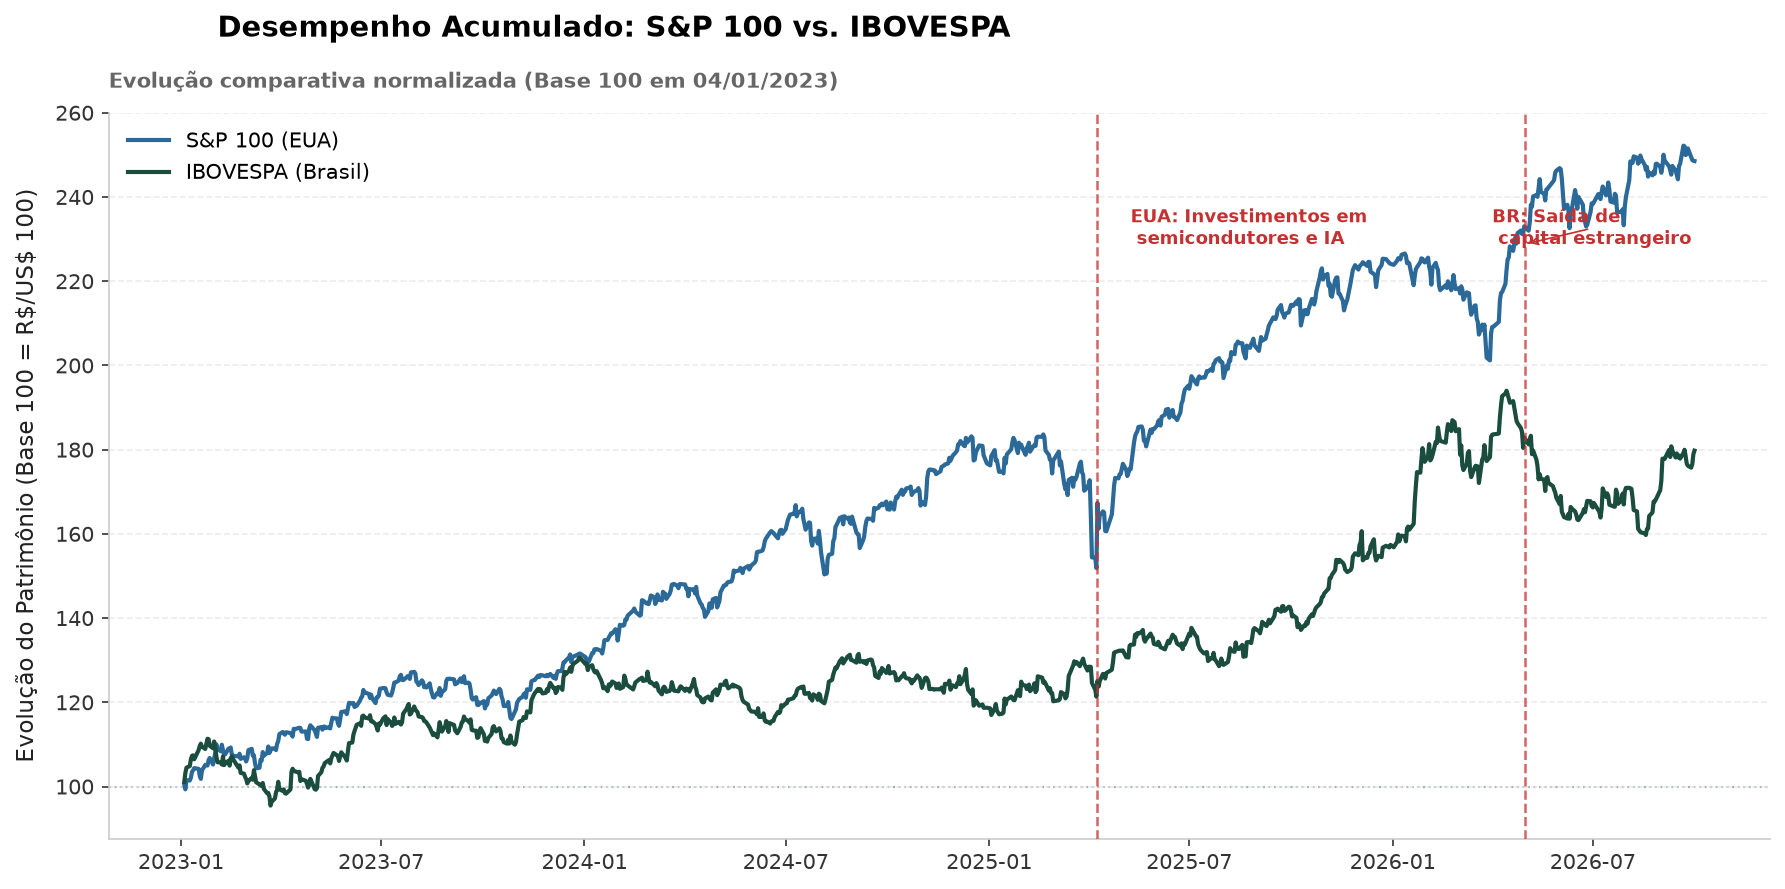

In [85]:
# ==============================================================================
# PASSO 4: GRÁFICO COMPARATIVO DE PERFORMANCE ACUMULADA DOS INDICES
# ==============================================================================
# Garante que as configurações visuais do NYT estão ativas
set_nyt_style()

# Criando figura com a interface Orientada a Objetos
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

# Linha de referência no ponto de partida (Base 100)
ax.axhline(y=100, color='#A0AEC0', linestyle=':', linewidth=1, zorder=1)

# Plot dos índices usando a paleta oficial padronizada do projeto
ax.plot(sp_acum.index, sp_acum, color='#2B6999', linewidth=2, label='S&P 100 (EUA)', zorder=2)
ax.plot(ib_acum.index, ib_acum, color='#1B4D3E', linewidth=2, label='IBOVESPA (Brasil)', zorder=2)

# Grid sutil apenas no eixo Y para não poluir
ax.grid(axis='y', color='#E5E5E5', linestyle='--', alpha=0.7)
ax.grid(axis='x', visible=False)

# Hierarquia do Título (Estilo Manchete Editorial NYT)
plt.suptitle('Desempenho Acumulado: S&P 100 vs. IBOVESPA', x=0.125, y=0.98, fontweight='bold', fontsize=14, ha='left')
ax.set_title(
    f"Evolução comparativa normalizada (Base 100 em {datas_comuns[0].strftime('%d/%m/%Y')})", 
    fontsize=10, color='#666666', pad=12, loc='left'
)

# 6. Marcação de Eventos Históricos de Mercado
data_baixa_B3 = pd.to_datetime('2026-05-01')
data_alta_usa = pd.to_datetime('2025-04-09')

# Linha e anotação: Mínimo no Brasil (Maio 2026)
ax.axvline(data_baixa_B3, color='#C53030', linestyle='--', linewidth=1.2, alpha=0.75, zorder=3)
ax.annotate('BR: Saída de \n capital estrangeiro', xy=(data_baixa_B3, ax.get_ylim()[1] * 0.88), 
            xytext=(data_baixa_B3 - pd.Timedelta(days=30), ax.get_ylim()[1] * 0.88),
            fontsize=8.5, color='#C53030', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#C53030', lw=0.8))

# Linha e anotação: Início dalta pontual histórica EUA (Mai 2025)
ax.axvline(data_alta_usa, color='#C53030', linestyle='--', linewidth=1.2, alpha=0.75, zorder=3)
ax.annotate('EUA: Investimentos em \n semicondutores e IA', xy=(data_alta_usa, ax.get_ylim()[1] * 0.88), 
            xytext=(data_alta_usa + pd.Timedelta(days=30), ax.get_ylim()[1] * 0.88),
            fontsize=8.5, color='#C53030', fontweight='bold')

# Ajuste dos eixos
ax.set_ylabel('Evolução do Patrimônio (Base 100 = R\\$/US\\$ 100)', fontsize=11, labelpad=8)
ax.set_xlabel('', fontsize=11) # Em séries de tempo, dispensamos a legenda "Data"

# Legenda limpa (sem moldura)
ax.legend(frameon=False, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('comparativo_acumulado_indices.png', dpi=300, bbox_inches='tight')
plt.show()

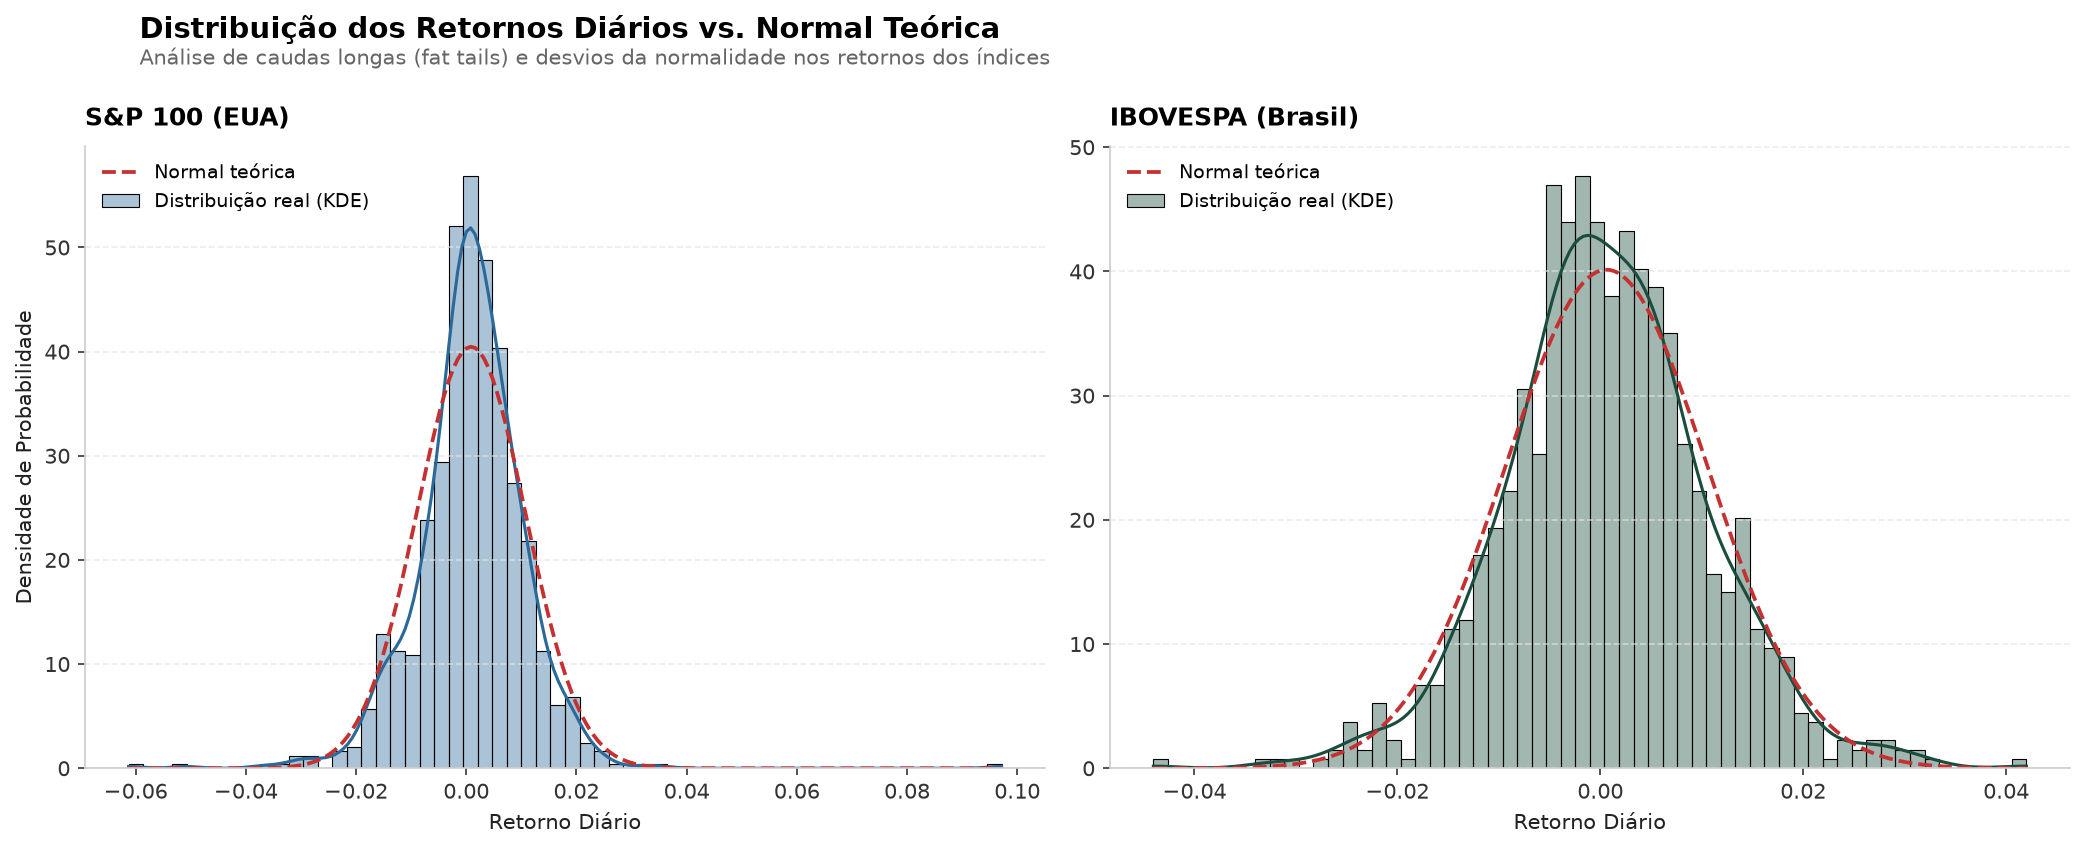

      ANÁLISE ESTATÍSTICA DE RISCO E DISTRIBUIÇÃO

--- ASSIMETRIA (SKEWNESS) ---
S&P 100:  0.35  (Normal = 0)
IBOVESPA: 0.03  (Normal = 0)

--- CURTOSE EM EXCESSO (KURTOSIS) ---
S&P 100:  12.15  (Normal = 0)
IBOVESPA: 1.10  (Normal = 0)

🔍 INTERPRETAÇÃO DOS RESULTADOS:
• Curtose > 0 (Fat Tails): Ambos os índices apresentam caudas gordas.
  Eventos extremos (choques e crises) ocorrem com frequência superior à prevista pela distribuição Normal.
• Assimetria < 0 (Negative Skew): Distribuição levemente inclinada à esquerda.
  Indica probabilidade maior de variações negativas intensas (quedas repentinas) do que de altas extremas.


In [63]:
# ==============================================================================
# GRÁFICO DE DISTRIBUIÇÃO DE RETORNOS VS. CURVA NORMAL 
# ==============================================================================
set_nyt_style()

# Extração segura dos valores numéricos para cálculo estatístico
s_sp_vals = ret_idx_sp["^OEX"].dropna()
s_ib_vals = ret_idx_ib["^BVSP"].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=150)

# ------------------------------------------------------------------------------
# PAINEL 1: S&P 100 (EUA)
# ------------------------------------------------------------------------------
# Histograma e KDE real normalizados por densidade
sns.histplot(s_sp_vals, bins=60, stat="density", kde=True, 
             color='#2B6999', alpha=0.4, ax=ax1, label='Distribuição real (KDE)')

# Cálculo da Curva Normal Teórica
mu_sp, sigma_sp = s_sp_vals.mean(), s_sp_vals.std()
x_sp = np.linspace(s_sp_vals.min(), s_sp_vals.max(), 200)
pdf_sp = (1 / (sigma_sp * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_sp - mu_sp) / sigma_sp) ** 2)

ax1.plot(x_sp, pdf_sp, color=CORES['alerta'], linestyle='--', linewidth=1.8, label='Normal teórica')

# Ajustes estéticos - Painel 1
ax1.set_title('S&P 100 (EUA)', fontsize=12, fontweight='bold', loc='left', pad=10)
ax1.set_xlabel('Retorno Diário', fontsize=10)
ax1.set_ylabel('Densidade de Probabilidade', fontsize=10)
ax1.grid(axis='y', color='#E5E5E5', linestyle='--', alpha=0.7)
ax1.grid(axis='x', visible=False)
ax1.legend(frameon=False, loc='upper left', fontsize=9)

# ------------------------------------------------------------------------------
# PAINEL 2: IBOVESPA (Brasil)
# ------------------------------------------------------------------------------
# Histograma e KDE real normalizados por densidade
sns.histplot(s_ib_vals, bins=60, stat="density", kde=True, 
             color='#1B4D3E', alpha=0.4, ax=ax2, label='Distribuição real (KDE)')

# Cálculo da Curva Normal Teórica
mu_ib, sigma_ib = s_ib_vals.mean(), s_ib_vals.std()
x_ib = np.linspace(s_ib_vals.min(), s_ib_vals.max(), 200)
pdf_ib = (1 / (sigma_ib * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_ib - mu_ib) / sigma_ib) ** 2)

ax2.plot(x_ib, pdf_ib, color=CORES['alerta'], linestyle='--', linewidth=1.8, label='Normal teórica')

# Ajustes estéticos - Painel 2
ax2.set_title('IBOVESPA (Brasil)', fontsize=12, fontweight='bold', loc='left', pad=10)
ax2.set_xlabel('Retorno Diário', fontsize=10)
ax2.set_ylabel('', fontsize=10) # Remove rótulo duplicado no segundo painel
ax2.grid(axis='y', color='#E5E5E5', linestyle='--', alpha=0.7)
ax2.grid(axis='x', visible=False)
ax2.legend(frameon=False, loc='upper left', fontsize=9)

# ------------------------------------------------------------------------------
# TÍTULO GERAL E CONFIGURAÇÕES FINAIS
# ------------------------------------------------------------------------------
plt.suptitle('Distribuição dos Retornos Diários vs. Normal Teórica', x=0.07, y=1.02, fontweight='bold', fontsize=14, ha='left')
fig.text(0.07, 0.96, 'Análise de caudas longas (fat tails) e desvios da normalidade nos retornos dos índices', fontsize=10, color='#666666')

plt.tight_layout()
plt.savefig('distribuicao_retornos.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# CÁLCULO E EXIBIÇÃO DA ASSIMETRIA E CURTOSE
# ==============================================================================
skew_sp = s_sp_vals.skew()
skew_ib = s_ib_vals.skew()

kurt_sp = s_sp_vals.kurtosis()
kurt_ib = s_ib_vals.kurtosis()

print("=" * 55)
print("      ANÁLISE ESTATÍSTICA DE RISCO E DISTRIBUIÇÃO")
print("=" * 55)
print("\n--- ASSIMETRIA (SKEWNESS) ---")
print(f"S&P 100:  {skew_sp:.2f}  (Normal = 0)")
print(f"IBOVESPA: {skew_ib:.2f}  (Normal = 0)")

print("\n--- CURTOSE EM EXCESSO (KURTOSIS) ---")
print(f"S&P 100:  {kurt_sp:.2f}  (Normal = 0)")
print(f"IBOVESPA: {kurt_ib:.2f}  (Normal = 0)")
print("=" * 55)

# INTERPRETAÇÃO FINANCEIRA
print("\n🔍 INTERPRETAÇÃO DOS RESULTADOS:")
print("• Curtose > 0 (Fat Tails): Ambos os índices apresentam caudas gordas.")
print("  Eventos extremos (choques e crises) ocorrem com frequência superior à prevista pela distribuição Normal.")
print("• Assimetria < 0 (Negative Skew): Distribuição levemente inclinada à esquerda.")
print("  Indica probabilidade maior de variações negativas intensas (quedas repentinas) do que de altas extremas.")

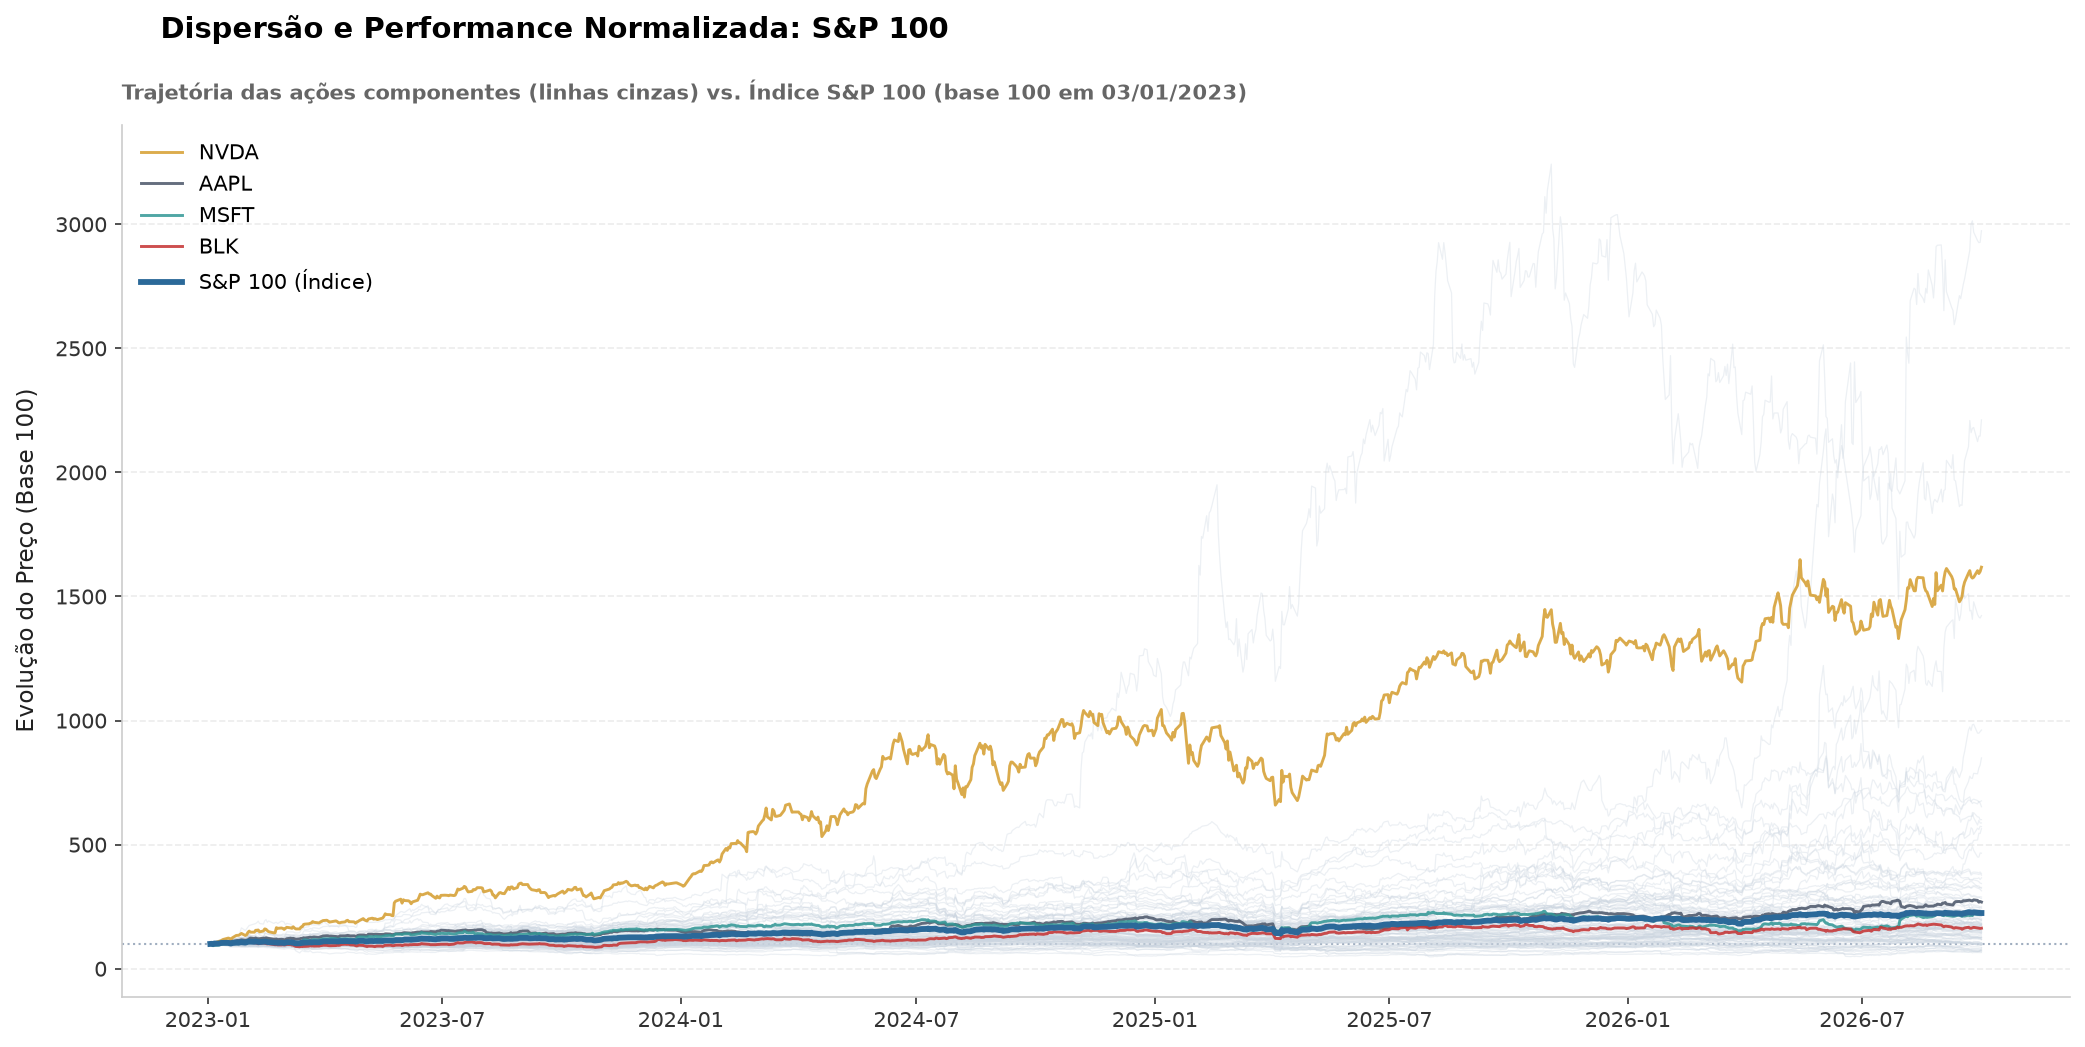

In [71]:
# ==============================================================================
# PERFORMANCE NORMALIZADA S&P 100
# ==============================================================================
set_nyt_style()

# 1. Cálculo da performance normalizada (Base 100 no início)
precos_norm_sp = (dados_sp100_clean / dados_sp100_clean.iloc[0] * 100)
indice_norm_sp = (indice_sp100 / indice_sp100.iloc[0] * 100)

fig, ax = plt.subplots(figsize=(14, 7), dpi=150)

# 2. Linha de referência na Base 100
ax.axhline(y=100, color='#A0AEC0', linestyle=':', linewidth=1, zorder=1)

# 3. Ações individuais em cinza sutil ao fundo ("Feixe de luz")
for col in precos_norm_sp.columns:
    ax.plot(precos_norm_sp.index, precos_norm_sp[col], color='#CBD5E0', linewidth=0.6, alpha=0.35, zorder=2)

# 4. Destacar ações chave em tons sóbrios
destaques = {
    'NVDA': '#D69E2E',  # Dourado/Amber para alto crescimento
    'AAPL': '#4A5568',  # Cinza Escuro Slate
    'MSFT': '#319795',  # Teal/Azul-Verde
    'BLK':  CORES['alerta']  # Carmesim para contraste de queda/volatilidade
}

for acao, cor in destaques.items():
    if acao in precos_norm_sp.columns:
        ax.plot(precos_norm_sp.index, precos_norm_sp[acao], color=cor, linewidth=1.4, alpha=0.85, label=acao, zorder=3)

# 5. Índice S&P 100 em Destaque Principal (Azul Oficial do Projeto)
ax.plot(indice_norm_sp.index, indice_norm_sp, color='#2B6999', linewidth=2.8, label='S&P 100 (Índice)', zorder=4)


# 7. Ajustes Estéticos e Grid
ax.set_yscale('linear') # Mantenha 'log' se o pico da NVDA for excessivo e achatar as outras
ax.set_ylabel('Evolução do Preço (Base 100)', fontsize=11, labelpad=8)
ax.set_xlabel('', fontsize=11)
ax.grid(axis='y', color='#E5E5E5', linestyle='--', alpha=0.7)
ax.grid(axis='x', visible=False)

# Legenda Limpa
ax.legend(frameon=False, loc='upper left', fontsize=10)

# 8. Títulos no estilo NYT
plt.suptitle('Dispersão e Performance Normalizada: S&P 100', x=0.08, y=0.99, fontweight='bold', fontsize=14, ha='left')
ax.set_title(
    f"Trajetória das ações componentes (linhas cinzas) vs. Índice S&P 100 (base 100 em {precos_norm_sp.index[0].strftime('%d/%m/%Y')})", 
    fontsize=10, color='#666666', pad=12, loc='left'
)

plt.tight_layout()
plt.savefig('performance_normalizada_sp100.png', dpi=300, bbox_inches='tight')
plt.show()

OSError: [Errno 22] Invalid argument: 'performance_normalizada_ibovespa.png'

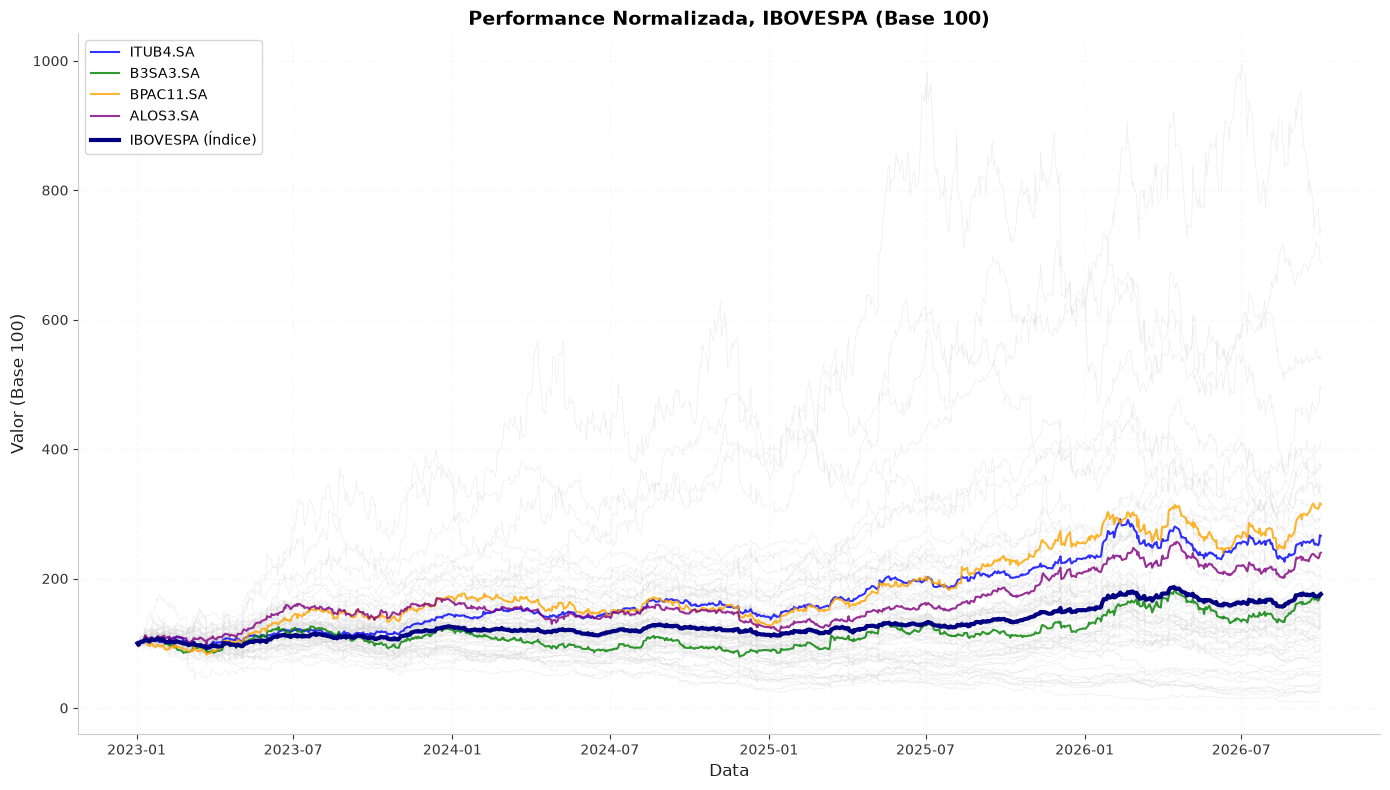

In [62]:
# ══════════════════════════════════════════════════════
# Performance Normalizada IBOVESPA
# ══════════════════════════════════════════════════════

# Performance normalizada: todos começam em 100 no início do período
precos_norm_ib = (dados_ibov_clean / dados_ibov_clean.iloc[0] * 100)
indice_norm_ib = (indice_ibov / indice_ibov.iloc[0] * 100)

plt.figure(figsize=(14, 8))

# Ações individuais em cinza claro (fundo)
for col in precos_norm_ib.columns:
    plt.plot(precos_norm_ib.index, precos_norm_ib[col], color='lightgray', linewidth=0.5, alpha=0.4)



# Destacar algumas ações relevantes
destaques = ['ITUB4.SA', 'B3SA3.SA', 'BPAC11.SA', 'ALOS3.SA']
cores_dest = ['blue', 'green', 'orange', 'purple']
for acao, cor in zip(destaques, cores_dest):
    if acao in precos_norm_ib.columns:
        plt.plot(precos_norm_ib.index, precos_norm_ib[acao], color=cor, linewidth=1.5, label=acao, alpha=0.8)

# Índice em destaque total
plt.plot(indice_norm_ib.index, indice_norm_ib, color='navy', linewidth=3, label='IBOVESPA (Índice)')

# Marcar eventos importantes

data_covid_inicio = pd.to_datetime('2020-03-23')
data_covid_fim = pd.to_datetime('2020-03-25')
#plt.axvline(data_covid_inicio, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
#plt.text(data_covid_fim, precos_norm_ib.max().max()*0.85, 'Mínimo\nCOVID', color='red', fontsize=9)

data_crise_juros_inicio = pd.to_datetime('2022-01-03')
data_crise_juros_fim = pd.to_datetime('2022-02-01')
#plt.axvline(data_crise_juros_inicio, color='darkred', linestyle=':', linewidth=1.5, alpha=0.7)
#plt.text(data_crise_juros_fim, precos_norm_ib.max().max()*0.70, 'Início\nCrise Juros', color='darkred', fontsize=9)

plt.title('Performance Normalizada, IBOVESPA (Base 100)', fontsize=14, fontweight='bold')
plt.ylabel('Valor (Base 100)', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('performance_normalizada_ibovespa.png', dpi=150)
plt.show()

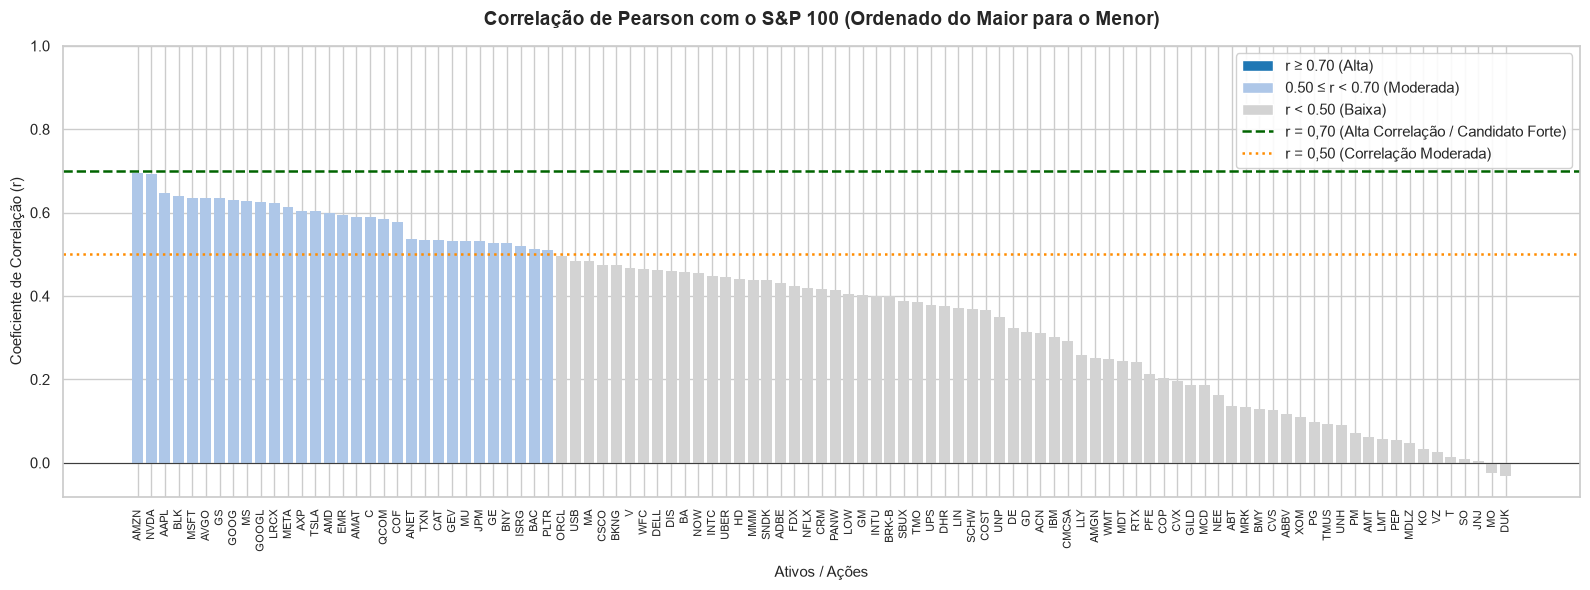

   PAINEL DE DESTAQUES DE CORRELAÇÃO - S&P 100
Top 15 Ativos r (Top) Bottom 10 Ativos r (Bottom)
         AMZN  0.6950              DUK    -0.0310
         NVDA  0.6935               MO    -0.0235
         AAPL  0.6466              JNJ     0.0043
          BLK  0.6409               SO     0.0088
         MSFT  0.6358                T     0.0137
         AVGO  0.6357               VZ     0.0253
           GS  0.6340               KO     0.0320
         GOOG  0.6298             MDLZ     0.0470
           MS  0.6272              PEP     0.0540
        GOOGL  0.6256              LMT     0.0559
         LRCX  0.6236              NaN        NaN
         META  0.6137              NaN        NaN
          AXP  0.6035              NaN        NaN
         TSLA  0.6031              NaN        NaN
          AMD  0.5998              NaN        NaN



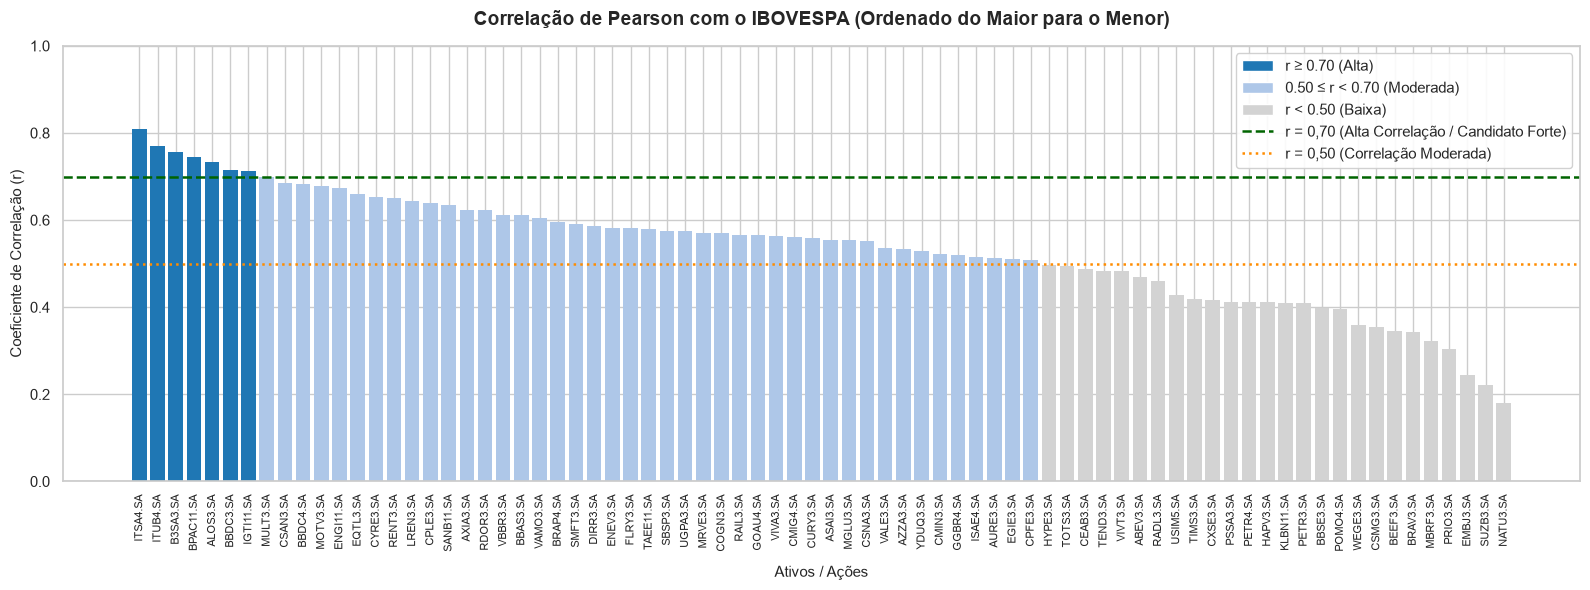

   PAINEL DE DESTAQUES DE CORRELAÇÃO - IBOVESPA
Top 15 Ativos r (Top) Bottom 10 Ativos r (Bottom)
     ITSA4.SA  0.8089         NATU3.SA     0.1792
     ITUB4.SA  0.7693         SUZB3.SA     0.2210
     B3SA3.SA  0.7567         EMBJ3.SA     0.2433
    BPAC11.SA  0.7454         PRIO3.SA     0.3044
     ALOS3.SA  0.7336         MBRF3.SA     0.3214
     BBDC3.SA  0.7144         BRAV3.SA     0.3439
    IGTI11.SA  0.7125         BEEF3.SA     0.3464
     MULT3.SA  0.6988         CSMG3.SA     0.3535
     CSAN3.SA  0.6851         WEGE3.SA     0.3598
     BBDC4.SA  0.6834         POMO4.SA     0.3966
     MOTV3.SA  0.6782              NaN        NaN
    ENGI11.SA  0.6743              NaN        NaN
     EQTL3.SA  0.6602              NaN        NaN
     CYRE3.SA  0.6531              NaN        NaN
     RENT3.SA  0.6505              NaN        NaN



In [ ]:
# ══════════════════════════════════════════════════════
# Correlação de Pearson de cada ação diretamente contra a série do índice
# ══════════════════════════════════════════════════════

# Configuração de estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

def analisar_correlacao_benchmark(ret_acoes, ret_indice, nome_indice):
    """
    Calcula a correlação de Pearson entre as ações e o índice,
    gera o gráfico de barras ordenado e exibe Top 15 / Bottom 10.
    """
    col_idx = ret_indice.columns[0]
    
    # 1. Cálculo da Correlação de Pearson para cada ação com o benchmark
    correlacoes = ret_acoes.apply(lambda col: col.corr(ret_indice[col_idx]))
    
    # Ordenar da maior para a menor correlação
    correlacoes_ord = correlacoes.sort_values(ascending=False)
    df_corr = pd.DataFrame({'Ativo': correlacoes_ord.index, 'Pearson_R': correlacoes_ord.values})
    
    # 2. Atribuição de Cores por Patamar de Correlação
    # Alta (>= 0.70): Azul escuro | Moderada (0.50 a 0.70): Azul claro | Baixa (< 0.50): Cinza
    def atribuir_cor(r):
        if r >= 0.70:
            return '#1f77b4'  # Azul escuro (Alta correlação)
        elif r >= 0.50:
            return '#aec7e8'  # Azul suave (Moderada)
        else:
            return '#d3d3d3'  # Cinza (Baixa correlação)

    cores = df_corr['Pearson_R'].apply(atribuir_cor)

    # 3. Gráfico de Barras Ordenado
    fig, ax = plt.subplots(figsize=(16, 6))
    
    bars = ax.bar(df_corr['Ativo'], df_corr['Pearson_R'], color=cores, edgecolor='none', width=0.8)
    
    # Linhas de Corte Visuais (Referência)
    ax.axhline(y=0.70, color='darkgreen', linestyle='--', linewidth=1.8, label='r = 0,70 (Alta Correlação / Candidato Forte)')
    ax.axhline(y=0.50, color='darkorange', linestyle=':', linewidth=1.8, label='r = 0,50 (Correlação Moderada)')
    ax.axhline(y=0.00, color='black', linestyle='-', linewidth=0.8, alpha=0.7)

    # Ajustes dos eixos e títulos
    ax.set_title(f'Correlação de Pearson com o {nome_indice} (Ordenado do Maior para o Menor)', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Ativos / Ações', fontsize=11, labelpad=10)
    ax.set_ylabel('Coeficiente de Correlação (r)', fontsize=11)
    ax.set_ylim(min(0, df_corr['Pearson_R'].min() - 0.05), 1.0)
    ax.tick_params(axis='x', rotation=90, labelsize=8)
    
    # Legenda customizada
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1f77b4', label='r ≥ 0.70 (Alta)'),
        Patch(facecolor='#aec7e8', label='0.50 ≤ r < 0.70 (Moderada)'),
        Patch(facecolor='#d3d3d3', label='r < 0.50 (Baixa)'),
        ax.get_legend_handles_labels()[0][0],
        ax.get_legend_handles_labels()[0][1]
    ]
    ax.legend(handles=legend_elements, loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
    
    plt.tight_layout()
    plt.show()
    
    # 4. Exibição do Top 15 vs Bottom 10 em tabelas formatadas
    top15 = df_corr.head(15).reset_index(drop=True)
    bottom10 = df_corr.tail(10).iloc[::-1].reset_index(drop=True) # Inverter para ver a menor no topo
    
    print("=" * 60)
    print(f"   PAINEL DE DESTAQUES DE CORRELAÇÃO - {nome_indice}")
    print("=" * 60)
    
    df_comparativo = pd.concat([
        top15.rename(columns={'Ativo': 'Top 15 Ativos', 'Pearson_R': 'r (Top)'}),
        bottom10.rename(columns={'Ativo': 'Bottom 10 Ativos', 'Pearson_R': 'r (Bottom)'})
    ], axis=1)
    
    print(df_comparativo.to_string(index=False, formatters={'r (Top)': '{:.4f}'.format, 'r (Bottom)': '{:.4f}'.format}))
    print("=" * 60 + "\n")
    
    return df_corr

# ---------------------------------------------------------
# EXECUÇÃO PARA S&P 100 E IBOVESPA
# ---------------------------------------------------------
# Assumindo que suas matrizes de retornos tratados estão carregadas:
corr_sp100 = analisar_correlacao_benchmark(ret_sp100, ret_idx_sp, "S&P 100")
corr_ibov = analisar_correlacao_benchmark(ret_ibov, ret_idx_ib, "IBOVESPA")

In [ ]:
# Cálculo do Beta em relação ao S&P 100
def calcular_metricas_replicacao(ret_acoes, ret_indice):
    col_idx = ret_indice.columns[0]
    var_indice = ret_indice[col_idx].var()
    
    metricas = []
    
    for col in ret_acoes.columns:
        r = ret_acoes[col].corr(ret_indice[col_idx])
        cov = ret_acoes[col].cov(ret_indice[col_idx])
        beta = cov / var_indice
        vol_acao = ret_acoes[col].std() * np.sqrt(252) # Volatilidade anualizada
        
        # Tracking error individual em relação ao índice
        te_individual = (ret_acoes[col] - ret_indice[col_idx]).std() * np.sqrt(252)
        
        metricas.append({
            'Ativo': col,
            'Pearson r': r,
            'Beta (β)': beta,
            'Volatilidade Anual': vol_acao,
            'Tracking Error Ind.': te_individual
        })
        
    df_metricas = pd.DataFrame(metricas).sort_values(by='Pearson r', ascending=False)
    return df_metricas

# Execução no S&P 100
df_analise_sp100 = calcular_metricas_replicacao(ret_sp100, ret_idx_sp)
df_analise_ibov = calcular_metricas_replicacao(ret_ibov, ret_idx_ib)

# Comparar com as Top 5 mais correlacionadas
print(df_analise_sp100.head(10).to_string(index=False, formatters={
    'Pearson r': '{:.4f}'.format,
    'Beta (β)': '{:.2f}'.format,
    'Volatilidade Anual': '{:.2%}'.format,
    'Tracking Error Ind.': '{:.2%}'.format
}))

print(df_analise_ibov.head(10).to_string(index=False, formatters={
    'Pearson r': '{:.4f}'.format,
    'Beta (β)': '{:.2f}'.format,
    'Volatilidade Anual': '{:.2%}'.format,
    'Tracking Error Ind.': '{:.2%}'.format
}))

Ativo Pearson r Beta (β) Volatilidade Anual Tracking Error Ind.
 AMZN    0.6950     1.44             32.35%              24.25%
 NVDA    0.6935     2.11             47.51%              38.35%
 AAPL    0.6466     1.06             25.71%              19.63%
  BLK    0.6409     0.99             24.19%              18.57%
 MSFT    0.6358     1.06             26.13%              20.20%
 AVGO    0.6357     1.89             46.49%              38.49%
   GS    0.6340     1.16             28.64%              22.29%
 GOOG    0.6298     1.22             30.36%              23.83%
   MS    0.6272     1.13             28.09%              21.97%
GOOGL    0.6256     1.22             30.60%              24.13%
    Ativo Pearson r Beta (β) Volatilidade Anual Tracking Error Ind.
 ITSA4.SA    0.8089     1.09             21.30%              12.61%
 ITUB4.SA    0.7693     1.07             21.93%              14.06%
 B3SA3.SA    0.7567     1.59             33.07%              23.51%
BPAC11.SA    0.7454     

Total de ações mapeadas no S&P 100: 101 de 101


C:\Users\nbago\AppData\Local\Temp\ipykernel_31092\1551960613.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


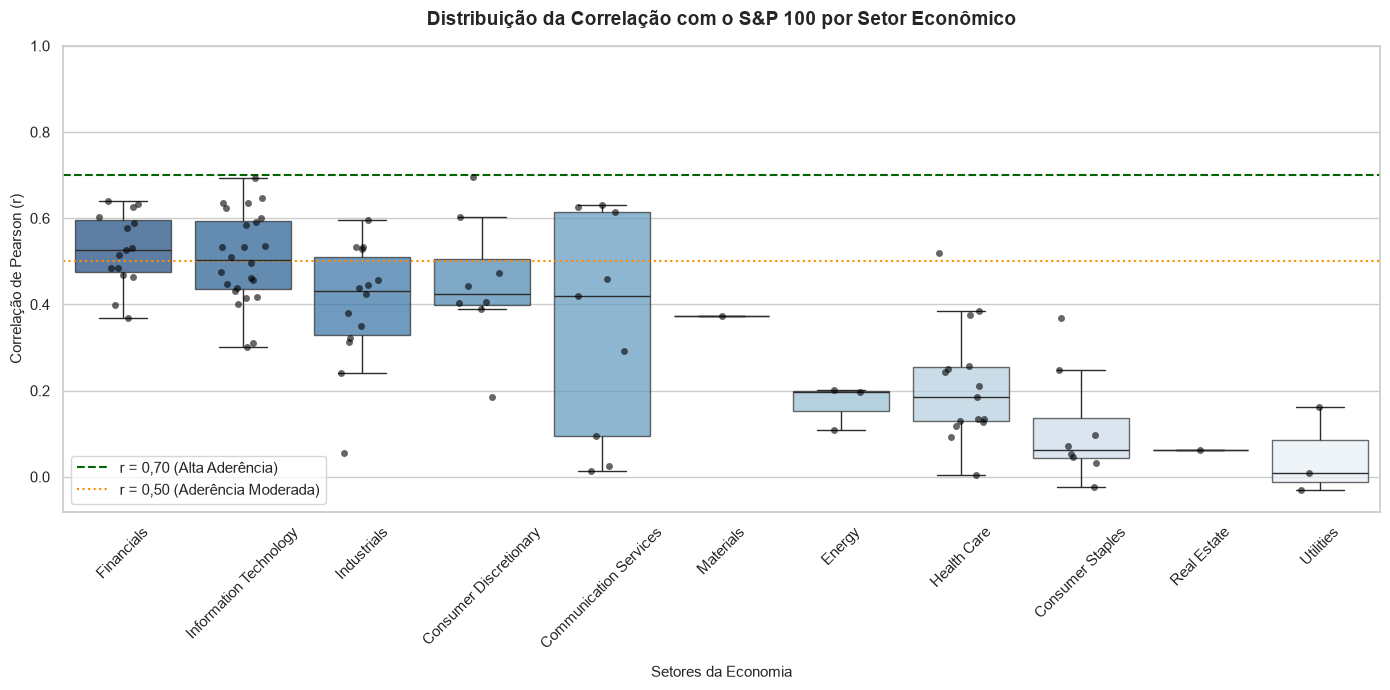

      RESUMO DE ADERÊNCIA SETORIAL AO S&P 100
                Sector  Qtd_Ações Mediana  Média Desvio_Padrão
            Financials         15  0.5263 0.5275        0.0844
Information Technology         24  0.5025 0.5072        0.1049
           Industrials         14  0.4312 0.4011        0.1407
Consumer Discretionary          8  0.4233 0.4495        0.1522
Communication Services          9  0.4202 0.3528        0.2570
             Materials          1  0.3720 0.3720           NaN
                Energy          3  0.1960 0.1692        0.0520
           Health Care         15  0.1863 0.2114        0.1334
      Consumer Staples          8  0.0631 0.1119        0.1298
           Real Estate          1  0.0627 0.0627           NaN
             Utilities          3  0.0088 0.0469        0.1024

Total de ações mapeadas no IBOVESPA: 76 de 76


C:\Users\nbago\AppData\Local\Temp\ipykernel_31092\1551960613.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


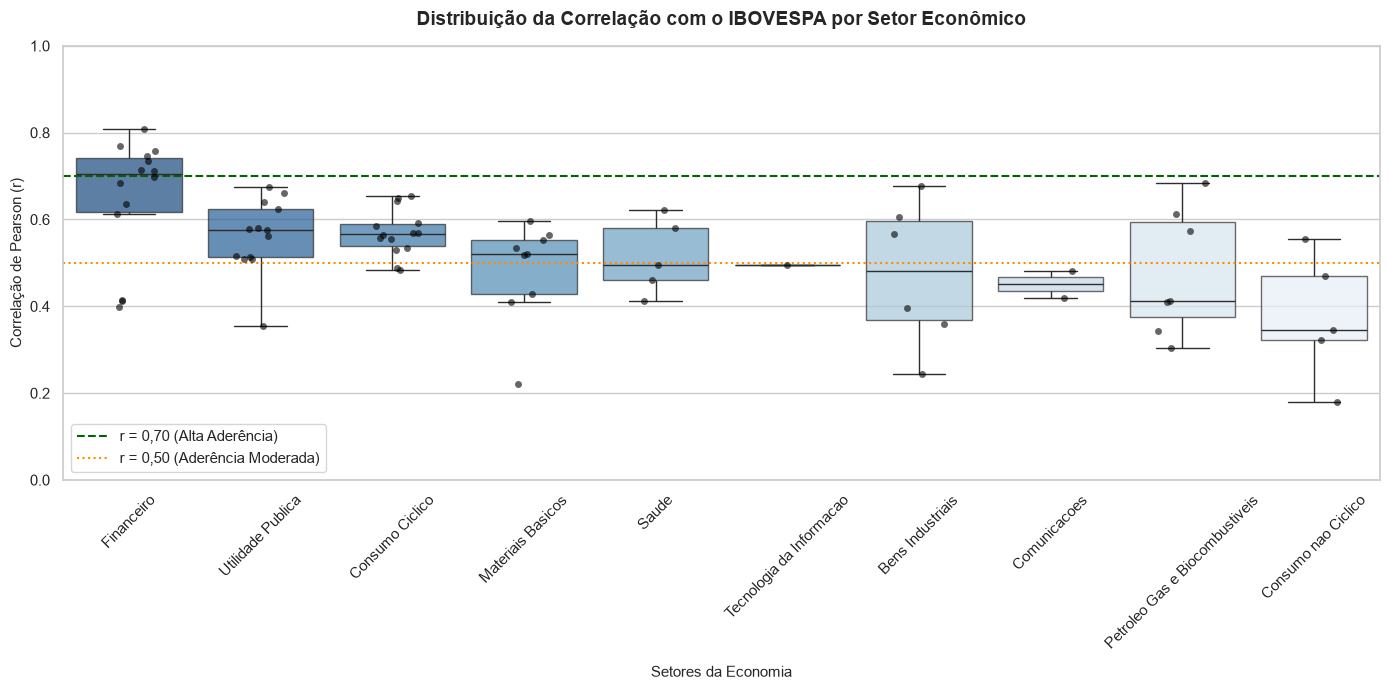

      RESUMO DE ADERÊNCIA SETORIAL AO IBOVESPA
                         Setor  Qtd_Ações Mediana  Média Desvio_Padrão
                    Financeiro         14  0.7056 0.6497        0.1401
             Utilidade Publica         13  0.5756 0.5613        0.0848
               Consumo Ciclico         14  0.5664 0.5696        0.0533
             Materiais Basicos          9  0.5210 0.4829        0.1155
                         Saude          5  0.4960 0.5142        0.0866
      Tecnologia da Informacao          1  0.4944 0.4944           NaN
              Bens Industriais          6  0.4814 0.4749        0.1672
                  Comunicacoes          2  0.4506 0.4506        0.0447
Petroleo Gas e Biocombustiveis          7  0.4116 0.4771        0.1457
           Consumo nao Ciclico          5  0.3464 0.3743        0.1444



In [ ]:
# Configuração estética do Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

def plotar_boxplot_correlacao_setorial(ret_acoes, ret_indice, path_csv_setores, col_ticker, col_setor, nome_indice):
    """
    Carrega o mapeamento setorial, calcula a correlação de Pearson por ativo,
    agrupa por setor e plota o Boxplot ordenado pela mediana.
    """
    col_idx = ret_indice.columns[0]
    
    # 1. Carregar mapeamento setorial do CSV
    df_setores = pd.read_csv(path_csv_setores)
    
    # Padronizar nomes de tickers (ex: remover espaços ou converter formatos se necessário)
    df_setores[col_ticker] = df_setores[col_ticker].astype(str).str.strip()
    
    # 2. Calcular correlação de Pearson de cada ação com o benchmark
    correlacoes = ret_acoes.apply(lambda col: col.corr(ret_indice[col_idx]))
    df_corr = pd.DataFrame({
        col_ticker: correlacoes.index,
        'Pearson_R': correlacoes.values
    })
    
    # Garantir compatibilidade de tickers entre o retorno e o arquivo de setores
    # Exemplo: Se os tickers do ret_acoes tiverem '.SA' (IBOV) ou '-B' (S&P), ajustamos no merge
    df_merged = pd.merge(df_corr, df_setores, on=col_ticker, how='inner')
    
    if df_merged.empty:
        # Tentativa de ajuste caso os tickers do CSV estejam sem sufixo .SA
        df_corr_temp = df_corr.copy()
        df_corr_temp[col_ticker] = df_corr_temp[col_ticker].str.replace('.SA', '', regex=False).str.replace('-', '.', regex=False)
        df_merged = pd.merge(df_corr_temp, df_setores, on=col_ticker, how='inner')
    
    print(f"Total de ações mapeadas no {nome_indice}: {len(df_merged)} de {ret_acoes.shape[1]}")
    
    # 3. Ordenar setores pela MEDIANA da correlação (do maior para o menor)
    ordem_setores = (
        df_merged.groupby(col_setor)['Pearson_R']
        .median()
        .sort_values(ascending=False)
        .index
    )
    
    # 4. Criar o Boxplot com sobreposição de pontos individuais (Swarmplot/Stripplot)
    fig, ax = plt.subplots(figsize=(14, 7))
    
    sns.boxplot(
        data=df_merged,
        x=col_setor,
        y='Pearson_R',
        order=ordem_setores,
        palette='Blues_r',
        ax=ax,
        fliersize=0,      # Oculta outliers do boxplot para não duplicar com o stripplot
        boxprops=dict(alpha=0.7)
    )
    
    # Sobreposição dos pontos das ações individuais para dar visibilidade ao N por setor
    sns.stripplot(
        data=df_merged,
        x=col_setor,
        y='Pearson_R',
        order=ordem_setores,
        color='black',
        alpha=0.6,
        jitter=0.2,
        size=5,
        ax=ax
    )
    
    # Linhas de referência de aderência
    ax.axhline(y=0.70, color='darkgreen', linestyle='--', linewidth=1.5, label='r = 0,70 (Alta Aderência)')
    ax.axhline(y=0.50, color='darkorange', linestyle=':', linewidth=1.5, label='r = 0,50 (Aderência Moderada)')
    
    # Títulos e formatação
    ax.set_title(f'Distribuição da Correlação com o {nome_indice} por Setor Econômico', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Setores da Economia', fontsize=11, labelpad=10)
    ax.set_ylabel('Correlação de Pearson (r)', fontsize=11)
    ax.set_ylim(min(0, df_merged['Pearson_R'].min() - 0.05), 1.0)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='lower left', frameon=True, facecolor='white')
    
    plt.tight_layout()
    plt.show()
    
    # 5. Tabela Resumo com Estatísticas Setoriais
    resumo_setorial = df_merged.groupby(col_setor)['Pearson_R'].agg(
        Qtd_Ações='count',
        Mediana='median',
        Média='mean',
        Desvio_Padrão='std'
    ).loc[ordem_setores].reset_index()
    
    print("=" * 65)
    print(f"      RESUMO DE ADERÊNCIA SETORIAL AO {nome_indice}")
    print("=" * 65)
    print(resumo_setorial.to_string(index=False, formatters={
        'Mediana': '{:.4f}'.format,
        'Média': '{:.4f}'.format,
        'Desvio_Padrão': '{:.4f}'.format
    }))
    print("=" * 65 + "\n")
    
    return df_merged, resumo_setorial

# ---------------------------------------------------------
# EXECUÇÃO PARA S&P 100 E IBOVESPA
# ---------------------------------------------------------
df_setores_sp100, resumo_sp100 = plotar_boxplot_correlacao_setorial(
    ret_acoes=ret_sp100,
    ret_indice=ret_idx_sp,
    path_csv_setores='SP100_wikipedia_21set2026.csv',
    col_ticker='Symbol',       # Ajuste se no seu CSV for 'Symbol'
    col_setor='Sector',         # Ajuste se no seu CSV for 'GICS Sector'
    nome_indice='S&P 100'
)

df_setores_ibov, resumo_ibov = plotar_boxplot_correlacao_setorial(
    ret_acoes=ret_ibov,
    ret_indice=ret_idx_ib,
    path_csv_setores='IBOVESPA_B3_24set2026.csv',
    col_ticker='Codigo',       # Ajuste se no seu CSV for 'Código'
    col_setor='Setor',          # Ajuste se no seu CSV for 'Setor Econômico'
    nome_indice='IBOVESPA'
)

=== SÍNTESE DE ADERÊNCIA AO BENCHMARK ===
Total de ações analisadas: 100
Ações com Alta Correlação (r >= 0.70):  0.0% das ações
Ações com Média Correlação (0.50 <= r < 0.70): 0.0% das ações

Top 5 Pilares do Índice (Maior Correlação):
Ticker
AAPL   NaN
ABBV   NaN
ABT    NaN
ACN    NaN
ADBE   NaN
dtype: float64

Bottom 5 Menos Correlacionadas:
Ticker
VZ     NaN
WFC    NaN
WMT    NaN
XOM    NaN
^OEX   NaN
dtype: float64


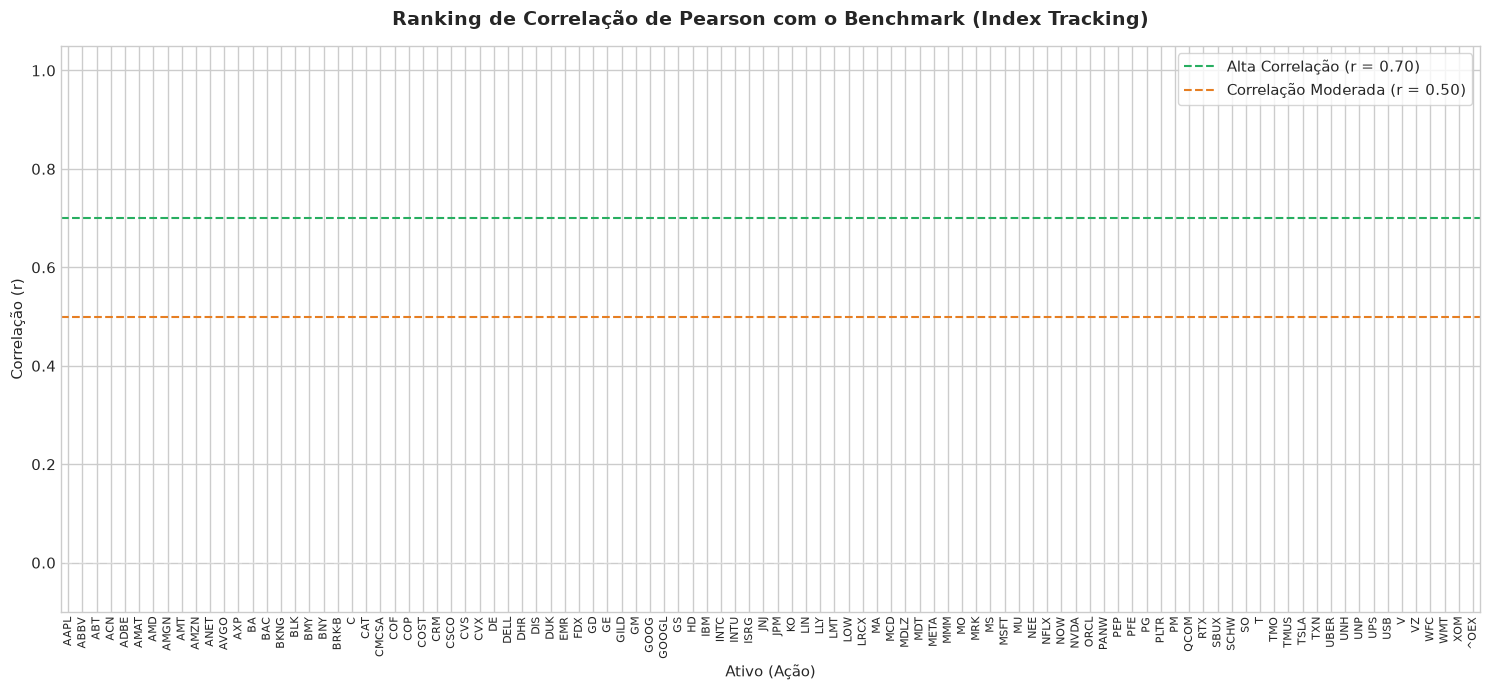

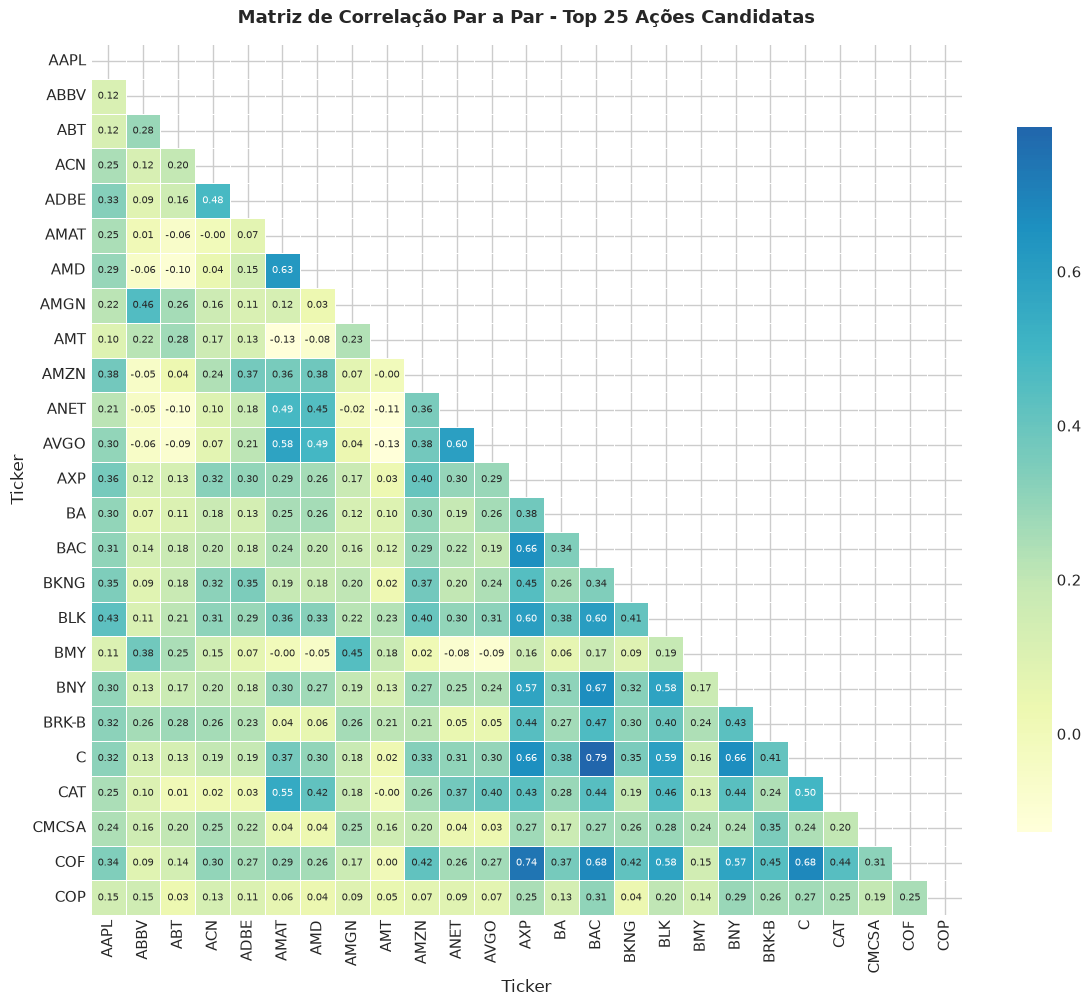


=== PARES DE ATIVOS REDUNDANTES (r > 0.90) ===
Foram encontrados 2 pares com correlação > 0.90:
Ação 1 Ação 2  Correlação
  GOOG  GOOGL      0.9972
  AMAT   LRCX      0.9078


"\nplt.figure(figsize=(12, 6))\nordem_setores = df_setorial.groupby('setor')['correlacao'].median().sort_values(ascending=False).index\n\nsns.boxplot(\n    data=df_setorial, \n    x='setor', \n    y='correlacao', \n    order=ordem_setores, \n    palette='Blues_r'\n)\n\nplt.title('Distribuição da Correlação com o Benchmark por Setor Econômico', fontsize=13, fontweight='bold')\nplt.xlabel('Setor Econômico', fontsize=11)\nplt.ylabel('Correlação com o Índice (r)', fontsize=11)\nplt.xticks(rotation=30)\nplt.tight_layout()\nplt.savefig('correlacao_por_setor_boxplot.png', dpi=300)\nplt.show()\n"

In [ ]:
# Configuração de estilo dos gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# ==============================================================================
# PASSO 1: SIMULAÇÃO / CARREGAMENTO DOS RETORNOS LOGARÍTMICOS
# (Substitua pelos seus DataFrames de retornos limpos 'ret_acoes' e 'ret_indice')
# ==============================================================================
# Exemplo de estrutura dos seus dados:
# ret_acoes : DataFrame onde cada coluna é um ticker (ex: AAPL, MSFT ou PETR4.SA, VALE3.SA)
# ret_indice: Series com os retornos logarítmicos do benchmark (^OEX ou ^BVSP)

# Garantir alinhamento temporal das datas entre ações e o índice
datas_comuns = ret_sp100_clean.index.intersection(ret_idx_sp.index)
ret_acoes_al = ret_sp100_clean.loc[datas_comuns]
ret_idx_al   = ret_idx_sp.loc[datas_comuns]

# ==============================================================================
# PASSO 2: CÁLCULO DA CORRELAÇÃO DE PEARSON COM O BENCHMARK
# ==============================================================================
# Calcular correlação de cada ação contra a série do índice
corr_com_idx = ret_acoes_al.corrwith(ret_idx_al).sort_values(ascending=False)

# Estatísticas sintéticas para a apresentação
pct_alta_corr = (corr_com_idx >= 0.70).mean() * 100
pct_media_corr = ((corr_com_idx >= 0.50) & (corr_com_idx < 0.70)).mean() * 100

print("=== SÍNTESE DE ADERÊNCIA AO BENCHMARK ===")
print(f"Total de ações analisadas: {len(corr_com_idx)}")
print(f"Ações com Alta Correlação (r >= 0.70):  {pct_alta_corr:.1f}% das ações")
print(f"Ações com Média Correlação (0.50 <= r < 0.70): {pct_media_corr:.1f}% das ações")
print("\nTop 5 Pilares do Índice (Maior Correlação):")
print(corr_com_idx.head(5).round(4))
print("\nBottom 5 Menos Correlacionadas:")
print(corr_com_idx.tail(5).round(4))

# ==============================================================================
# PASSO 3: GRÁFICO DE BARRAS RANQUEADO (RANKING DE CORRELAÇÃO)
# ==============================================================================
plt.figure(figsize=(15, 7))

# Definir cores por faixas de correlação
cores = [
    '#2b5c8f' if c >= 0.70 else ('#e67e22' if c >= 0.50 else '#c0392b')
    for c in corr_com_idx.values
]

corr_com_idx.plot(kind='bar', color=cores, edgecolor='white', linewidth=0.3)

# Linhas de referência operacionais
plt.axhline(0.70, color='#27ae60', linestyle='--', linewidth=1.5, label='Alta Correlação (r = 0.70)')
plt.axhline(0.50, color='#e67e22', linestyle='--', linewidth=1.5, label='Correlação Moderada (r = 0.50)')

plt.title('Ranking de Correlação de Pearson com o Benchmark (Index Tracking)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ativo (Ação)', fontsize=11)
plt.ylabel('Correlação (r)', fontsize=11)
plt.xticks(rotation=90, fontsize=8)
plt.ylim(-0.1, 1.05)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.savefig('ranking_correlacao_benchmark.png', dpi=300)
plt.show()

# ==============================================================================
# PASSO 4: MATRIZ DE CORRELAÇÃO PAR A PAR E IDENTIFICAÇÃO DE REDUNDÂNCIAS (r > 0.90)
# ==============================================================================
# Mapear matriz de correlação das 25 ações mais representativas
top25_tickers = corr_com_idx.head(25).index
corr_matrix_top25 = ret_acoes_al[top25_tickers].corr()

# Plotar Heatmap usando triângulo inferior
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix_top25, dtype=bool))

sns.heatmap(
    corr_matrix_top25,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    center=0.5,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 7}
)

plt.title('Matriz de Correlação Par a Par - Top 25 Ações Candidatas', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('heatmap_pares_redundantes.png', dpi=300)
plt.show()

# Identificar automaticamente pares de ações redundantes (r > 0.90)
matriz_completa = ret_acoes_al.corr()
pares_redundantes = []

for i in range(len(matriz_completa.columns)):
    for j in range(i + 1, len(matriz_completa.columns)):
        r_val = matriz_completa.iloc[i, j]
        if r_val > 0.90:
            pares_redundantes.append({
                'Ação 1': matriz_completa.columns[i],
                'Ação 2': matriz_completa.columns[j],
                'Correlação': round(r_val, 4)
            })

df_redundantes = pd.DataFrame(pares_redundantes).sort_values('Correlação', ascending=False)

print("\n=== PARES DE ATIVOS REDUNDANTES (r > 0.90) ===")
if len(df_redundantes) > 0:
    print(f"Foram encontrados {len(df_redundantes)} pares com correlação > 0.90:")
    print(df_redundantes.to_string(index=False))
else:
    print("Nenhum par com correlação superior a 0.90 foi identificado.")

# ==============================================================================
# PASSO 5: ANÁLISE DE CORRELAÇÃO POR SETOR ECONÔMICO (BOXPLOT)
# ==============================================================================
# Exemplo de dicionário de setores (Ajuste para os tickers da sua base)
# No S&P 100: AAPL='Tecnologia', JPM='Financeiro', XOM='Energia', etc.
# No IBOVESPA: PETR4.SA='Petróleo', VALE3.SA='Commodities', ITUB4.SA='Financeiro', etc.

# Exemplo genérico de estruturação:
df_setorial = pd.DataFrame({
    'ticker': corr_com_idx.index,
    'correlacao': corr_com_idx.values
})

# Se você possuir o mapeamento dos setores no seu dataset:
# df_setorial['setor'] = df_setorial['ticker'].map(dicionario_setores).fillna('Outros')

# Descomente o trecho abaixo quando o dicionário de setores estiver preenchido:
"""
plt.figure(figsize=(12, 6))
ordem_setores = df_setorial.groupby('setor')['correlacao'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df_setorial, 
    x='setor', 
    y='correlacao', 
    order=ordem_setores, 
    palette='Blues_r'
)

plt.title('Distribuição da Correlação com o Benchmark por Setor Econômico', fontsize=13, fontweight='bold')
plt.xlabel('Setor Econômico', fontsize=11)
plt.ylabel('Correlação com o Índice (r)', fontsize=11)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('correlacao_por_setor_boxplot.png', dpi=300)
plt.show()
"""